In [4]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import corner
import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [5]:
dco_types = const.DCO_TYPES.copy()

In [6]:
pops = {
    dco_type: cogsworth.pop.load(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial_sigma_bug/{dco_type}_in_band.h5") for dco_type in dco_types
}

cogsworth warning: file was saved with COSMIC v4.2.0 but you are using v4.2.1
cogsworth warning: file was saved with COSMIC v4.2.0 but you are using v4.2.1
cogsworth warning: file was saved with COSMIC v4.2.0 but you are using v4.2.1
cogsworth warning: file was saved with COSMIC v4.2.0 but you are using v4.2.1
cogsworth warning: file was saved with COSMIC v4.2.0 but you are using v4.2.1


In [7]:
for dco_type in dco_types:
    pop = pops[dco_type]
    print(dco_type)
    pop.final_pos, pop.final_vel

BHBH
BHNS
BHWD
NSNS
NSWD


In [8]:
detectable_pops = {}
for dco_type in dco_types:
    mask = (
        (pops[dco_type].bpp["snr_lisa_10yr_final_pos"] > 7)
        | (pops[dco_type].bpp["snr_lisa_10yr_initial_pos"] > 7)
        | (pops[dco_type].bpp["snr_decigo_10yr_final_pos"] > 7)
        | (pops[dco_type].bpp["snr_decigo_10yr_initial_pos"] > 7)
    )
    detectable_pops[dco_type] = pops[dco_type][mask]

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If y

In [9]:
f_detect_dfs = {
    dco_type: pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial_sigma_bug/{dco_type}_f_detect.h5", key="f_detect") for dco_type in dco_types
}

In [10]:
detectable_sources = {}
for dco_type in dco_types:
    print(dco_type)
    path = f"/mnt/ceph/users/twagg/lisa-dcos/fiducial_sigma_bug/{dco_type}_detectable_sources.h5"
    if os.path.isfile(path):
        detectable_sources[dco_type] = lw.source.Source.from_file(path)
    else:
        # turn them into a LEGWORK source class
        detectable_sources[dco_type] = detectable_pops[dco_type].to_legwork_sources(assume_mw_galactocentric=True)
        detectable_sources[dco_type].n_proc = 30

        # find those that haven't reached RLOF yet evolve them via GWs until present day
        if "rlof_time" not in detectable_pops[dco_type].bpp.columns:
             detectable_pops[dco_type].bpp["rlof_time"] = 1e20

        reached_rlof = detectable_pops[dco_type].initial_galaxy.tau > detectable_pops[dco_type].bpp["rlof_time"].values * u.Myr

        non_rlof_sources = detectable_sources[dco_type][~reached_rlof]
        non_rlof_sources.evolve_sources(t_evol=detectable_pops[dco_type].initial_galaxy.tau[~reached_rlof] - detectable_pops[dco_type].bpp["tphys"].values[~reached_rlof] * u.Myr)

        # recombine into a single source class
        detectable_sources[dco_type].m_1[~reached_rlof] = non_rlof_sources.m_1
        detectable_sources[dco_type].m_2[~reached_rlof] = non_rlof_sources.m_2
        detectable_sources[dco_type].dist[~reached_rlof] = non_rlof_sources.dist
        detectable_sources[dco_type].ecc[~reached_rlof] = non_rlof_sources.ecc
        detectable_sources[dco_type].f_orb[~reached_rlof] = non_rlof_sources.f_orb
        detectable_sources[dco_type].merged[~reached_rlof] = non_rlof_sources.merged

        detectable_sources[dco_type].save(path, overwrite=True)

BHBH
BHNS
BHWD
NSNS
NSWD


In [11]:
lisa_4yr_pops = {dco_type: detectable_pops[dco_type][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7] for dco_type in dco_types}
lisa_4yr_sources = {dco_type: detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7] for dco_type in dco_types}

In [12]:
wdwd_dist = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version="v2"))
wdwd_dist.sample(500_000)

In [128]:
unc_data = {}
for dco_type in const.DCO_TYPES:
    lisa_4yr_sources[dco_type].n_proc = 28
    if lisa_4yr_sources[dco_type].snr is None:
        lisa_4yr_sources[dco_type].get_snr(verbose=True)
    snr_uncertainty, snr_ratio, detectable_harmonics, max_harmonics = unc.get_ecc_uncertainty_stats(lisa_4yr_sources[dco_type], harmonic_threshold=7)
    f_orb_dot = lw.utils.fn_dot(lisa_4yr_sources[dco_type].m_c, lisa_4yr_sources[dco_type].f_orb, lisa_4yr_sources[dco_type].ecc, n=1)
    delta_m_c_over_m_c = unc.get_m_c_uncertainty(
        f_orb=lisa_4yr_sources[dco_type].f_orb, f_orb_dot=f_orb_dot, ecc=lisa_4yr_sources[dco_type].ecc,
        ecc_uncertainty=snr_uncertainty, snr=lisa_4yr_sources[dco_type].snr, t_obs=4 * u.yr
    )
    sigma_theta = unc.sky_localisation(
        lisa_4yr_sources[dco_type].snr,
        lisa_4yr_sources[dco_type].f_orb * lisa_4yr_sources[dco_type].max_snr_harmonic
    )
    delta_d_over_d = unc.get_D_uncertainty(
        snr=lisa_4yr_sources[dco_type].snr,
        f_dom=lisa_4yr_sources[dco_type].f_orb * lisa_4yr_sources[dco_type].max_snr_harmonic,
        m_c=lisa_4yr_sources[dco_type].m_c,
        t_obs=4 * u.yr
    )

    coords = lisa_4yr_pops[dco_type].get_final_mw_skycoord().galactic
    sigma_z = lisa_4yr_sources[dco_type].dist * np.sqrt(
        np.sin(coords.b.rad)**2 * delta_d_over_d**2 + np.cos(coords.b.rad)**2 * sigma_theta.to(u.rad).value**2
    )

    delta_forb = unc.get_f_orb_uncertainty(
        snr=lisa_4yr_sources[dco_type].snr, t_obs=4 * u.yr, f_orb=lisa_4yr_sources[dco_type].f_orb
    ) * lisa_4yr_sources[dco_type].f_orb

    unc_data[dco_type] = {
        "snr_uncertainty": snr_uncertainty,
        "snr_ratio": snr_ratio,
        "detectable_harmonics": detectable_harmonics,
        "max_harmonics": max_harmonics,
        "delta_m_c_over_m_c": delta_m_c_over_m_c,
        "sigma_theta": sigma_theta,
        "delta_d_over_d": delta_d_over_d,
        "sigma_z": sigma_z,
        "delta_forb": delta_forb
    }

In [131]:
def bootstrap_cdf(data, n_samples=25_000, n_bootstraps=10, n_bins=250, weights=None, norm=False, fig=None, ax=None,
                  reversed_cdf=True,
                  xlim=(0, np.inf), colour=None, label=None, med_kwargs={}, fill_kwargs={}):
    if fig is None or ax is None:
        fig, ax = plt.subplots()

    if weights is None:
        weights = np.ones(len(data))

    default_med_kwargs = {'color': colour, 'lw': 3, 'label': label}
    default_fill_kwargs = {'color': colour, 'alpha': 0.15, 'lw': 1}
    med_kwargs_comb = default_med_kwargs.copy()
    med_kwargs_comb.update(med_kwargs)
    fill_kwargs_comb = default_fill_kwargs.copy()
    fill_kwargs_comb.update(fill_kwargs)

    sample_inds = np.random.choice(len(data), size=(n_samples, n_bootstraps), replace=True)
    samples = data[sample_inds]
    sample_weights = weights[sample_inds]
    order = np.argsort(samples, axis=0)

    # apply order to samples and weights to get the CDFs, can't just immediately mask
    # ensure that shapes are the same after resorting!
    ordered_samples = np.take_along_axis(samples, order, axis=0)
    ordered_weights = np.take_along_axis(sample_weights, order, axis=0)

    cdfs = np.cumsum(ordered_weights, axis=0)
    if reversed_cdf:
        cdfs = cdfs.max() - cdfs
    if norm:
        cdfs /= cdfs.max(axis=0)

    # bin the CDFs to make them have a consistent x-axis for plotting
    bin_edges = np.linspace(*xlim, n_bins)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    binned_cdfs = np.zeros((len(bin_centres), n_bootstraps))
    for i in range(n_bootstraps):
        binned_cdfs[:, i] = np.interp(bin_centres, ordered_samples[:, i], cdfs[:, i])

    med = np.median(binned_cdfs, axis=1)
    low = np.percentile(binned_cdfs, 25, axis=1)
    high = np.percentile(binned_cdfs, 75, axis=1)

    ax.fill_between(bin_centres, low, high, **fill_kwargs_comb)
    ax.plot(bin_centres, med, **med_kwargs_comb)
    ax.set_yscale('log')

    return fig, ax, ordered_samples, bin_centres, med, low, high

# Measurement plots

## All together

In [130]:
unc_data[dco_type]["delta_forb"]

<Quantity [3.93733569e-10, 7.10347224e-10, 1.92271614e-10, ...,
           4.16790144e-10, 6.49021538e-10, 6.25118282e-10] Hz>

BHBH first crosses WDWD at 4.80 kpc
BHNS first crosses WDWD at 4.80 kpc
BHWD never crosses WDWD
NSNS first crosses WDWD at 6.08 kpc
NSWD first crosses WDWD at 4.40 kpc


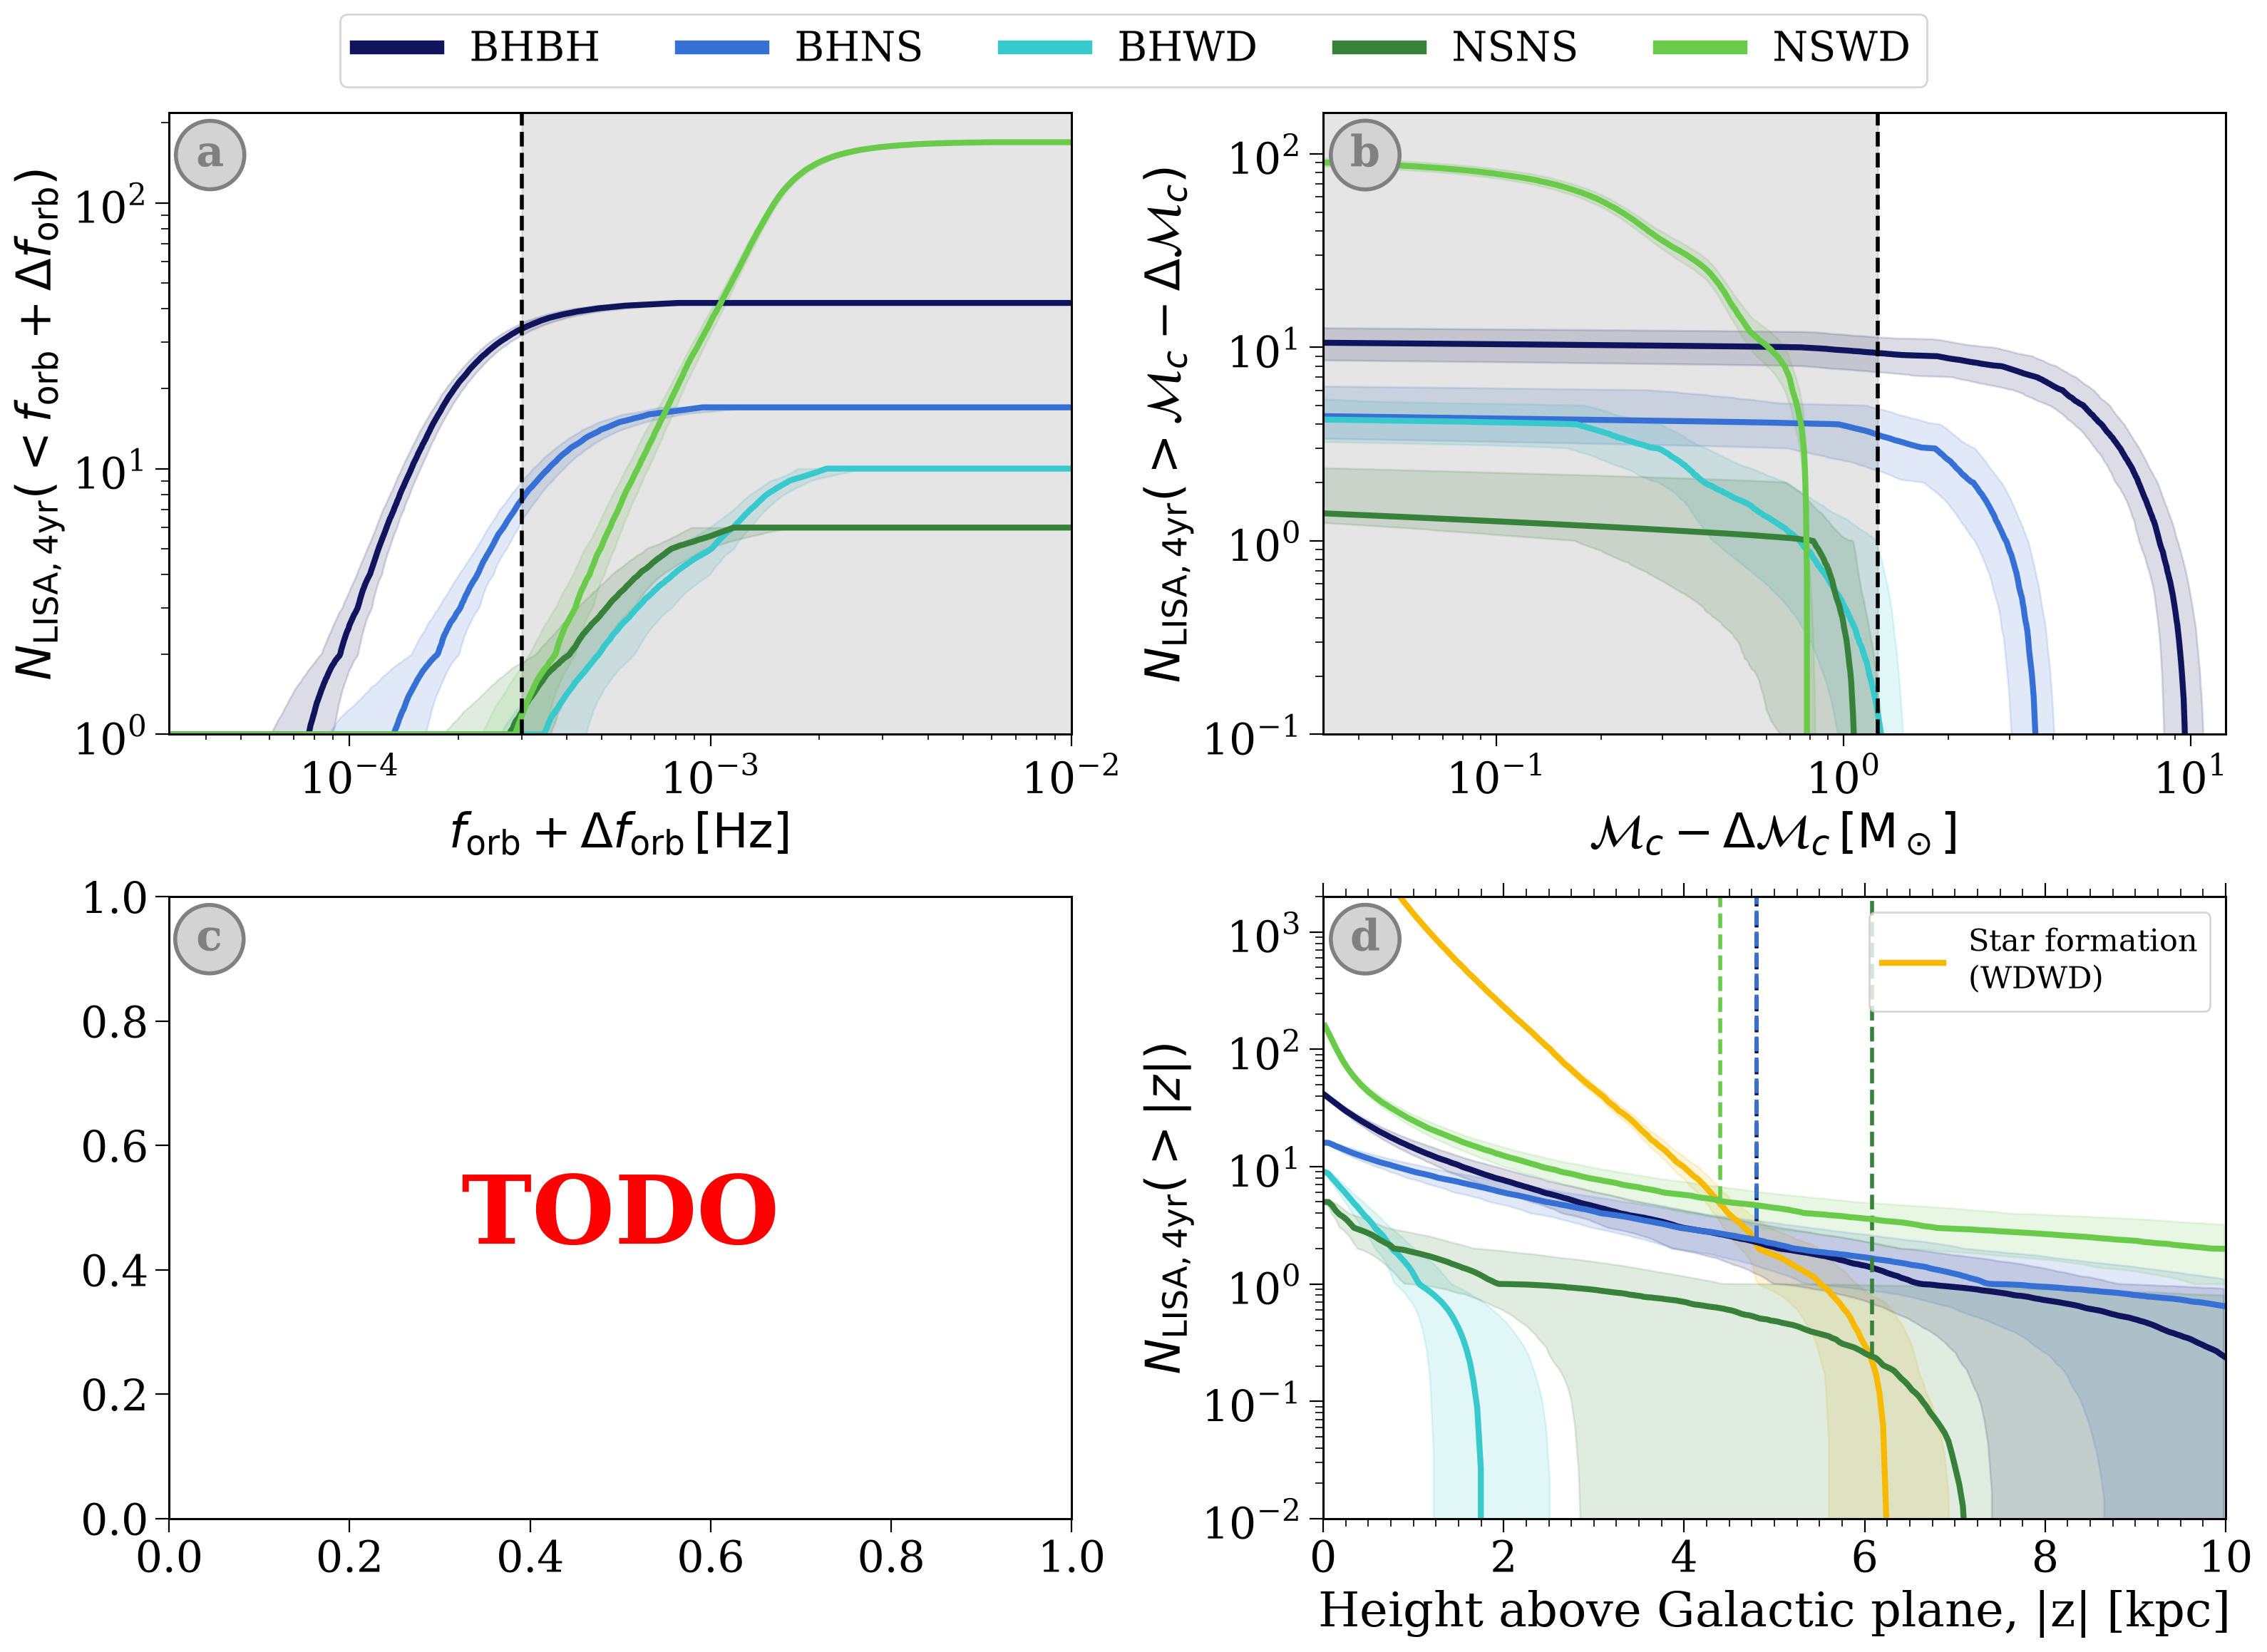

In [153]:
reload(plotting)

counts = {
    "BHBH": 42,
    "BHNS": 17,
    "BHWD": 10,
    "NSNS": 6,
    "NSWD": 169
}
N_BOOT = 2000

height_where_exceeds_wdwds = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11), layout="tight")

_, _, _, _, wdwd_med, _, _ = bootstrap_cdf(
    np.abs(wdwd_dist[wdwd_dist.tau < 100 * u.Gyr].z.value), n_samples=25_000, n_bootstraps=N_BOOT, norm=False,
    colour=const.STAR_COLOUR, fig=fig, ax=axes[1, 1], label="Star formation\n(WDWD)", xlim=(0, 10)
);

for dco_type in const.DCO_TYPES:
    w = lisa_4yr_pops[dco_type].initC["weights"]

    max_measured_forb = lisa_4yr_sources[dco_type].f_orb + unc_data[dco_type]["delta_forb"]
    bootstrap_cdf(np.log10(max_measured_forb.value), n_samples=counts[dco_type], n_bootstraps=N_BOOT, n_bins=1000,
                  norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[0, 0], label=dco_type, xlim=(-4.5, -2),
                  reversed_cdf=False)

    min_measured_mass = lisa_4yr_sources[dco_type].m_c - unc_data[dco_type]["delta_m_c_over_m_c"] * lisa_4yr_sources[dco_type].m_c
    min_measured_mass[min_measured_mass < 0] = min(abs(min_measured_mass))

    bootstrap_cdf(np.log10(min_measured_mass.value), n_samples=counts[dco_type], n_bootstraps=N_BOOT, n_bins=1000,
                  norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[0, 1], label=dco_type, xlim=(-1.5, 1.1))
        # bootstrap_cdf(min_measured_mass.value, n_samples=counts[dco_type], n_bootstraps=10000, norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=ax, label=dco_type, xlim=(0, 12))
        # plt.hist(np.log10(min_measured_mass.value), bins=np.linspace(-2, 1.5, 50), weights=w, histtype="step", lw=2, color=const.DCO_COLOURS[dco_type], label=dco_type, cumulative=True)


    _, _, _, bin_centres, dco_med, _, _ = bootstrap_cdf(
        np.abs(detectable_pops[dco_type].final_pos[:, 2].value), n_samples=counts[dco_type], n_bootstraps=N_BOOT,
        norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[1, 1], xlim=(0, 10)
    );
    above = bin_centres[dco_med > wdwd_med]
    if len(above) > 0:
        first_crossing = above[0]
        height_where_exceeds_wdwds[dco_type] = first_crossing
        print(f"{dco_type} first crosses WDWD at {first_crossing:1.2f} kpc")

        # ax.axvline(first_crossing, 0.7, 1, color=const.DCO_COLOURS[dco_type], ls="--", lw=1.5)
        axes[1, 1].plot([first_crossing, first_crossing], [dco_med[dco_med > wdwd_med][0], 2e3], color=const.DCO_COLOURS[dco_type], ls="--", lw=2)

    else:
        height_where_exceeds_wdwds[dco_type] = np.inf
        print(f"{dco_type} never crosses WDWD")

axes[0, 0].axvline(np.log10(3e-4), color='k', ls="--", lw=2)
axes[0, 0].axvspan(np.log10(3e-4), -2, color='k', alpha=0.1)
axes[0, 0].set(
    xlim=(-4.5, -2),
    xlabel=r"$f_{\rm orb} + \Delta f_{\rm orb} \, [\rm Hz]$",
    ylabel=r"$N_{\rm LISA, 4yr} (< f_{\rm orb} + \Delta f_{\rm orb})$",
    ylim=(1, None),
)

axes[1, 1].legend(fontsize=0.65 * fs)
axes[1, 1].set_xlim(0, 10)
axes[1, 1].set_ylim(1e-2, 2e3)

axes[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(0.25))

top_ax = axes[1, 1].secondary_xaxis('top')
top_ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
top_ax.set_xticklabels([])

axes[1, 1].set(
    xlabel="Height above Galactic plane, |z| [kpc]",
    ylabel=r"$N_{\rm LISA, 4yr} (> |z|)$"
)
    
axes[0, 1].set(
    # yscale="linear",
    # ylim=(0, None),
    ylim=(1e-1, None),
    xlim=(-1.5, 1.1),
    xlabel=r"$\mathcal{M}_c - \Delta \mathcal{M}_c \, [\rm M_\odot]$",
    ylabel=r"$N_{\rm LISA, 4yr} (> \mathcal{M}_c - \Delta \mathcal{M}_c)$"
)
max_wdwd_mass = lw.utils.chirp_mass(1.44, 1.44)
axes[0, 1].axvline(np.log10(max_wdwd_mass), color='k', ls="--", lw=2)
axes[0, 1].axvspan(-1.5, np.log10(max_wdwd_mass), color='k', alpha=0.1)

for ax in [axes[0, 0], axes[0, 1]]:
    plotting.fake_log_axis(ax, axis="x")

handles, labels = axes[0, 1].get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(7)
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=0.85*fs, bbox_to_anchor=(0.5, 0.99))

for letter, ax in zip("abcd", axes.flatten()):
    ax.annotate(letter, xy=(0.03, 0.94), xycoords="axes fraction", ha='left', va="center_baseline", fontsize=0.9*fs, color="grey", fontweight="bold",
                bbox=dict(boxstyle="circle", facecolor="lightgrey", edgecolor="grey", linewidth=2))

axes[1, 0].annotate("TODO", xy=(0.5, 0.5), xycoords="axes fraction", ha='center', va="center_baseline", fontsize=2*fs, color="red", fontweight="bold")

plt.savefig("../plots/dco_measured_properties.pdf", bbox_inches="tight")
plt.show()

In [ ]:
for dco_type in const.DCO_TYPES:
    print(dco_type)
    w = lisa_4yr_pops[dco_type].initC["weights"]

    # compute the fraction of sources that are too massive to be WDs after accounting for uncertainties in m_c
    max_wd_chirp_mass = lw.utils.chirp_mass(1.44 * u.Msun, 1.44 * u.Msun)
    too_massive = lisa_4yr_sources[dco_type].m_c - unc_data[dco_type]["delta_m_c_over_m_c"] * lisa_4yr_sources[dco_type].m_c > max_wd_chirp_mass
    print(f"  {w[too_massive].sum() / w.sum():1.2f} of sources are too massive to be WDs")

    # compute the fraction that are too low frequency to be WDs
    min_WD_f_orb = 3e-4 * u.Hz
    too_low_freq = lisa_4yr_sources[dco_type].f_orb < min_WD_f_orb
    print(f"  {w[too_low_freq].sum() / w.sum():1.2f} of sources are too low frequency to be WDs")

    # which ones have measurable eccentricity
    measureable_eccentricity_opt = lisa_4yr_sources[dco_type].ecc > 0.01
    measureable_eccentricity_pess = unc_data[dco_type]["snr_uncertainty"] < 0.5

    at_least_two_harmonics = unc_data[dco_type]["detectable_harmonics"] > 1
    print(f"  {w[measureable_eccentricity_opt].sum() / w.sum():1.2f} of sources have measureable eccentricity according to Nishizawa+2016")
    print(f"  {w[at_least_two_harmonics].sum() / w.sum():1.2f} of sources have at least two detectable harmonics")

    # far from plane
    far_from_plane = np.abs(lisa_4yr_pops[dco_type].final_pos[:, 2]) - unc_data[dco_type]["sigma_z"] > height_where_exceeds_wdwds[dco_type] * u.kpc
    print(f"  {w[far_from_plane].sum() / w.sum():1.2f} of sources are far enough above the plane to be more likely to be non-WD according to the WDWD distribution")

    print(f"  --------------\n  {w[too_massive | too_low_freq | at_least_two_harmonics].sum() / w.sum():1.2f} of {dco_type}s match at least one of the above criteria for being a non-WD DCO")
    print(f"  --------------\n  {w[too_massive | too_low_freq | at_least_two_harmonics | far_from_plane].sum() / w.sum():1.2f} of {dco_type}s match at least one of the above criteria for being a non-WD DCO")
    print("  --------------")

BHBH
  0.24 of sources are too massive to be WDs
  0.77 of sources are too low frequency to be WDs
  0.64 of sources have measureable eccentricity according to Nishizawa+2016
  0.06 of sources have at least two detectable harmonics
  0.01 of sources are far enough above the plane to be more likely to be non-WD according to the WDWD distribution
  --------------
  0.95 of BHBHs match at least one of the above criteria for being a non-WD DCO
  --------------
  0.95 of BHBHs match at least one of the above criteria for being a non-WD DCO
  --------------
BHNS
  0.25 of sources are too massive to be WDs
  0.42 of sources are too low frequency to be WDs
  0.84 of sources have measureable eccentricity according to Nishizawa+2016
  0.14 of sources have at least two detectable harmonics
  0.04 of sources are far enough above the plane to be more likely to be non-WD according to the WDWD distribution
  --------------
  0.69 of BHNSs match at least one of the above criteria for being a non-WD DC

## Chirp mass

BHBH
0.235547353087111
BHNS
0.2532813081480915
BHWD
0.08703323343208927
NSNS
0.09016478597407457
NSWD
0.0


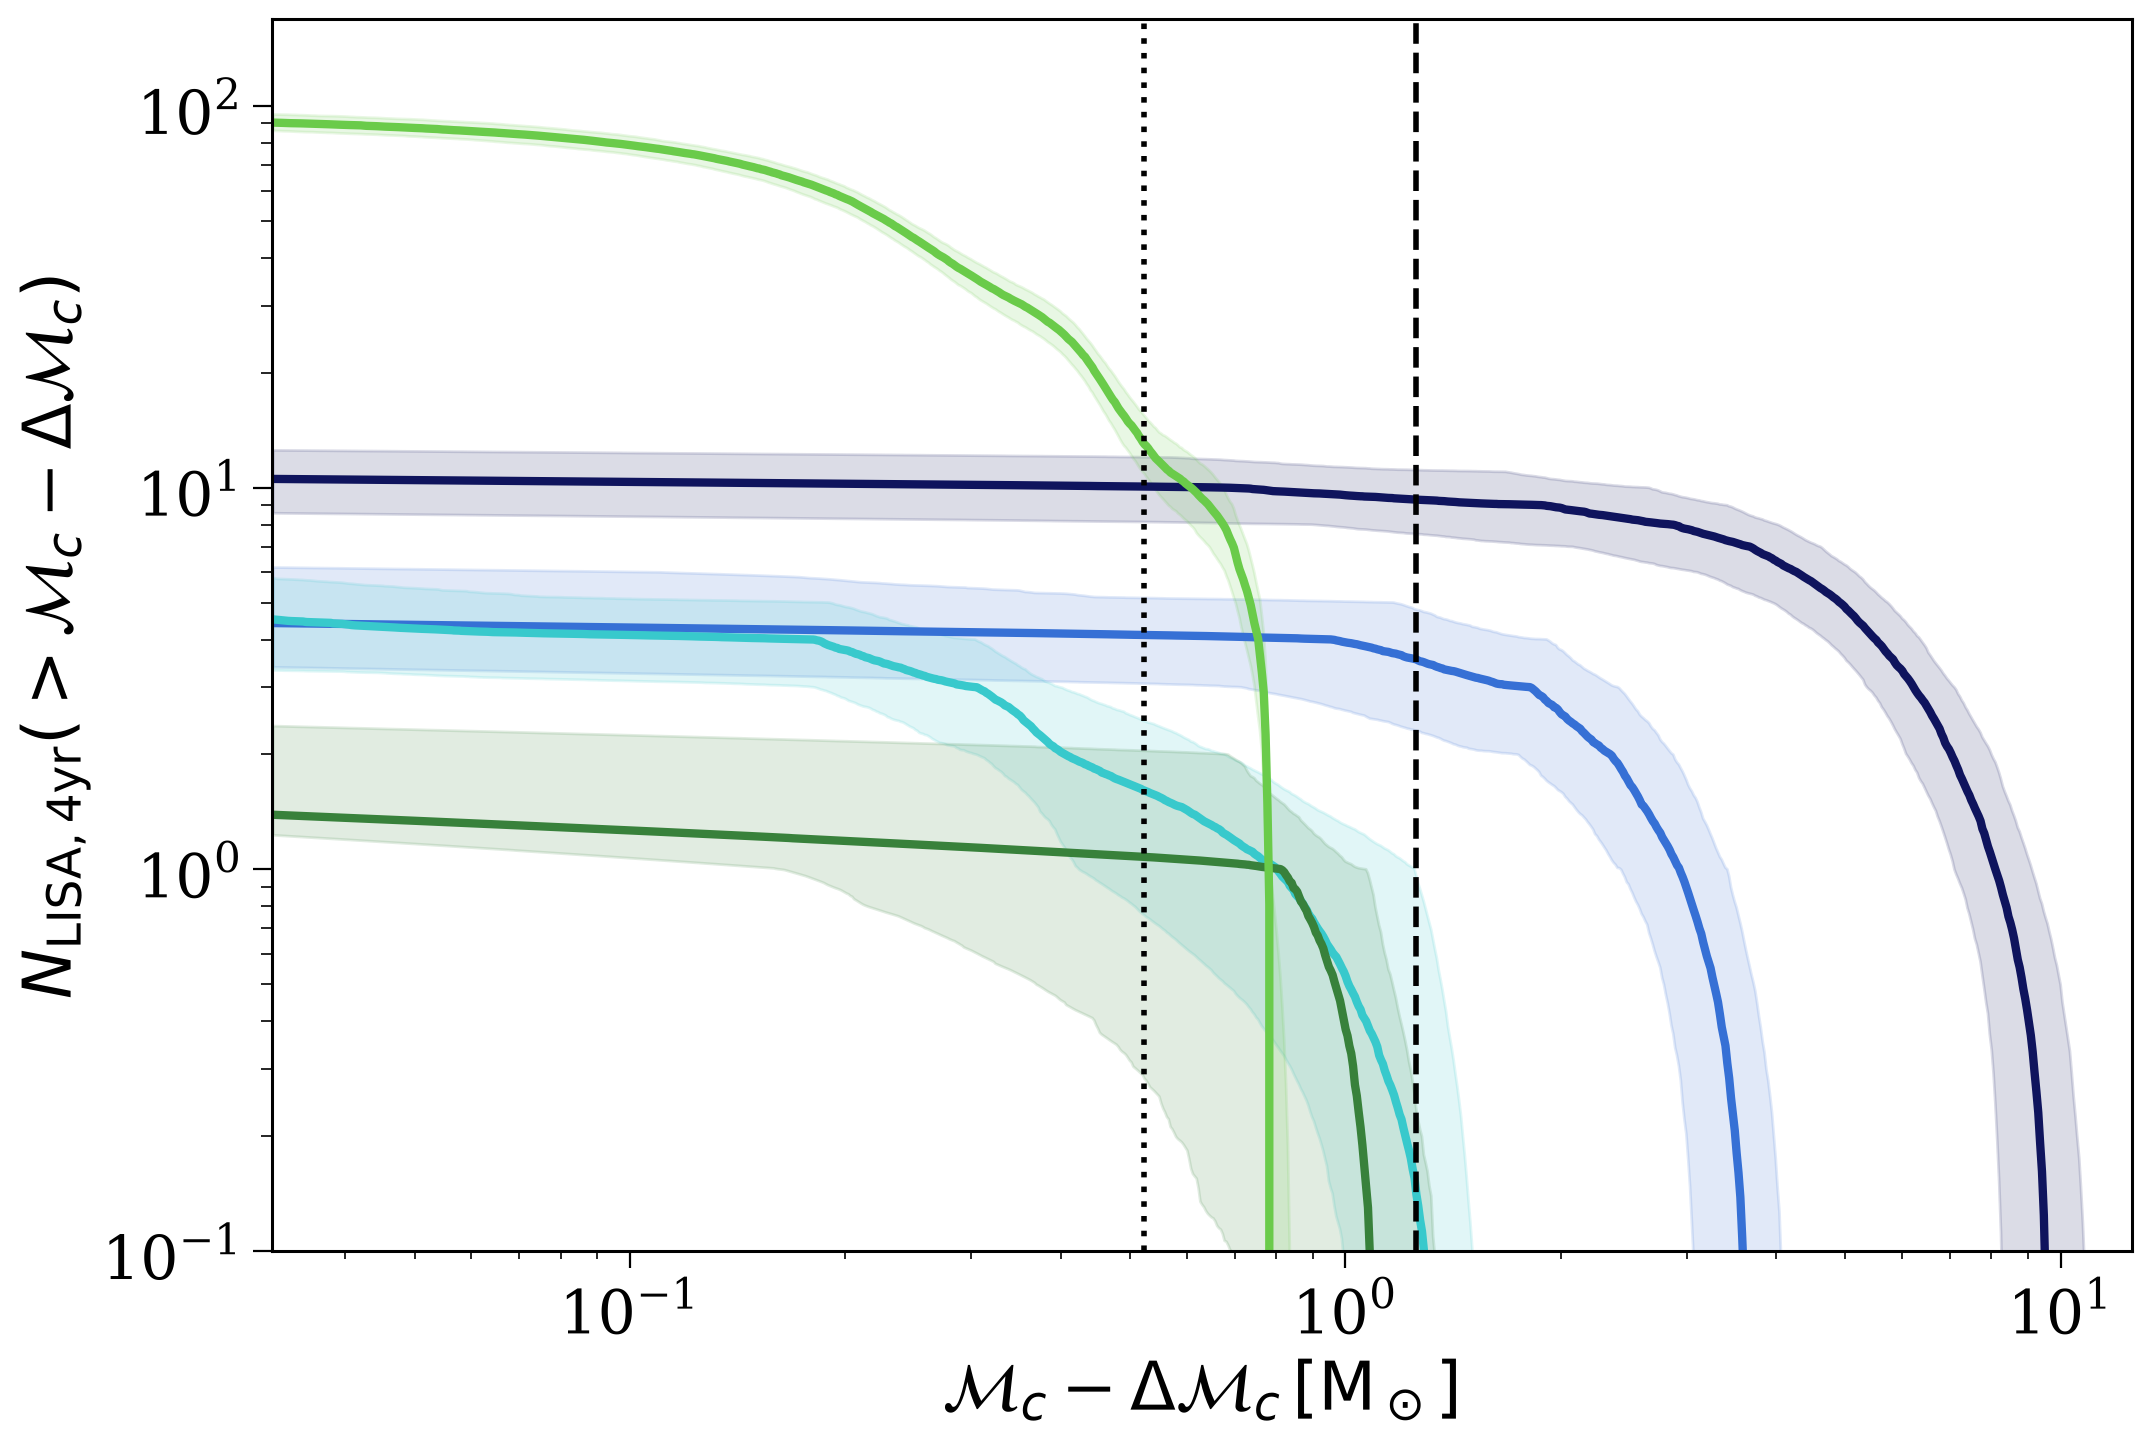

In [114]:
fig, ax = plt.subplots()

for dco_type in const.DCO_TYPES:
    # if "WD" in dco_type:
    #     continue
    print(dco_type)
    w = lisa_4yr_pops[dco_type].initC["weights"]

    min_measured_mass = lisa_4yr_sources[dco_type].m_c - unc_data[dco_type]["delta_m_c_over_m_c"] * lisa_4yr_sources[dco_type].m_c
    min_measured_mass[min_measured_mass < 0] = min(abs(min_measured_mass))

    print(np.sum(w[min_measured_mass > lw.utils.chirp_mass(1.44 * u.Msun, 1.44 * u.Msun)] / np.sum(w)))

    bootstrap_cdf(np.log10(min_measured_mass.value), n_samples=counts[dco_type], n_bootstraps=2000, n_bins=1000,
                  norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=ax, label=dco_type, xlim=(-1.5, 1.1))
    # bootstrap_cdf(min_measured_mass.value, n_samples=counts[dco_type], n_bootstraps=10000, norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=ax, label=dco_type, xlim=(0, 12))
    # plt.hist(np.log10(min_measured_mass.value), bins=np.linspace(-2, 1.5, 50), weights=w, histtype="step", lw=2, color=const.DCO_COLOURS[dco_type], label=dco_type, cumulative=True)

ax.set(
    # yscale="linear",
    # ylim=(0, None),
    ylim=(1e-1, None),
    xlim=(-1.5, 1.1),
    xlabel=r"$\mathcal{M}_c - \Delta \mathcal{M}_c \, [\rm M_\odot]$",
    ylabel=r"$N_{\rm LISA, 4yr} (> \mathcal{M}_c - \Delta \mathcal{M}_c)$"
)

# ax.axvline(max_wd_chirp_mass.value, color="k", ls="--", lw=2, label="Max WD chirp mass")
ax.axvline(np.log10(lw.utils.chirp_mass(0.6, 0.6)), color='k', ls=":", lw=2, label="Max WD chirp mass")
ax.axvline(np.log10(lw.utils.chirp_mass(1.44, 1.44)), color='k', ls="--", lw=2, label="Max WD chirp mass")

plotting.fake_log_axis(ax, axis="x")

plt.show()

# Old

(0.0, 1.0)

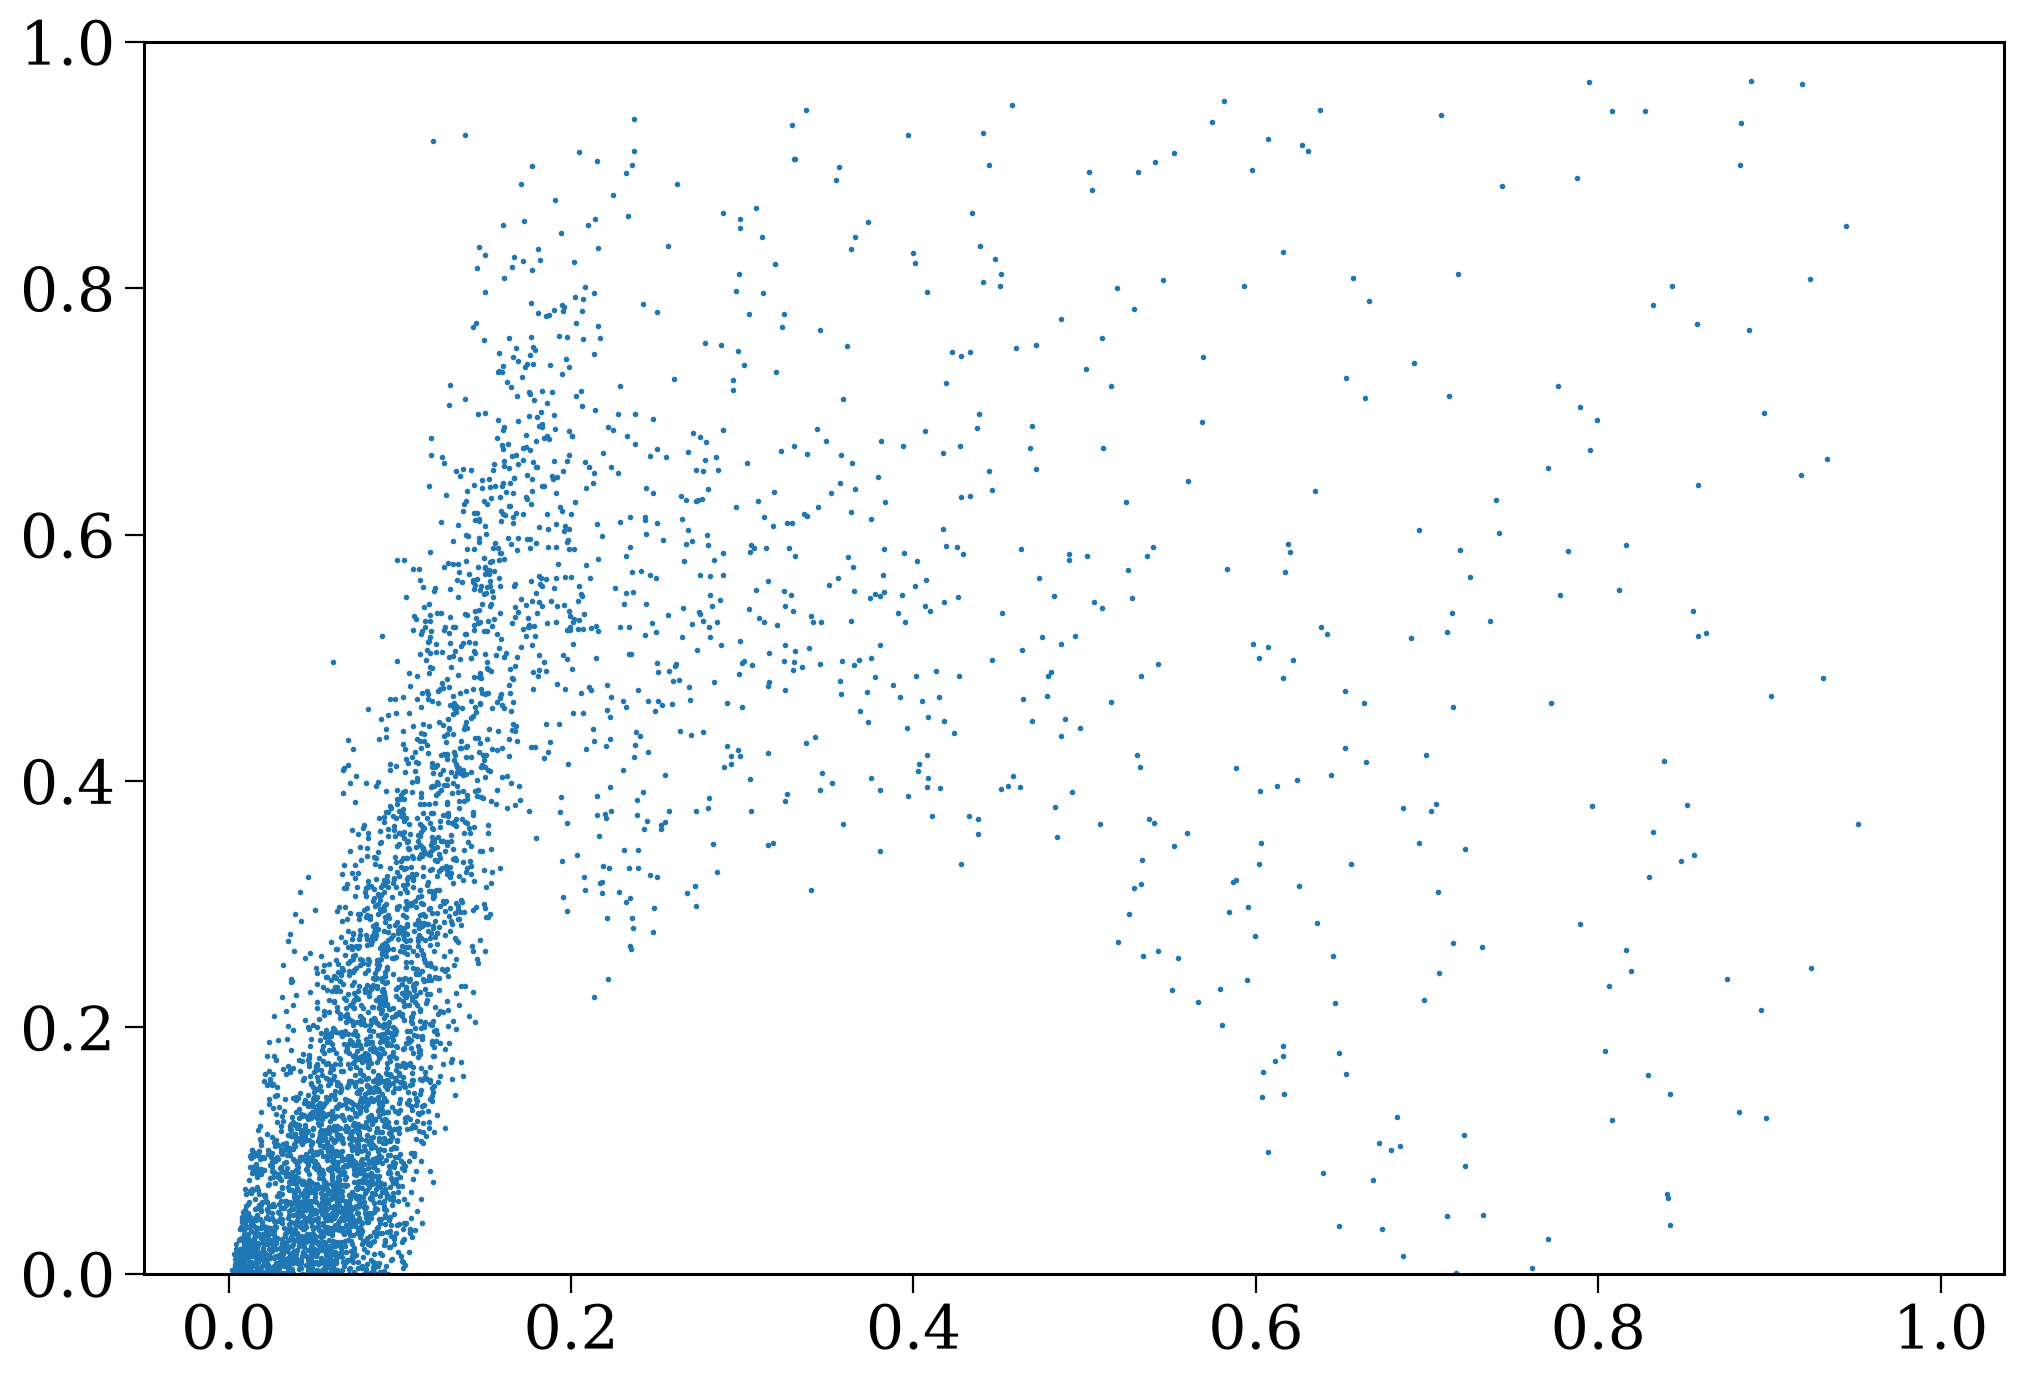

In [35]:
plt.scatter(lisa_4yr_sources["BHBH"].ecc, (unc_data["BHBH"]["snr_ratio"] - unc_data["BHBH"]["snr_uncertainty"]), s=1)
plt.ylim(0, 1)

In [47]:
def nishizawa_uncertainty(dist, m_c, ecc):
    eps0 = 2.2e-6
    eps0=1e-5
    gamma_m = 2.19
    gamma_e = 1.5
    return (eps0 * (dist / (400 * u.Mpc)) * (30 * u.Msun / m_c)** gamma_m * (0.1 / ecc)**gamma_e).decompose()

Text(0, 0.5, '$\\Delta e / e$')

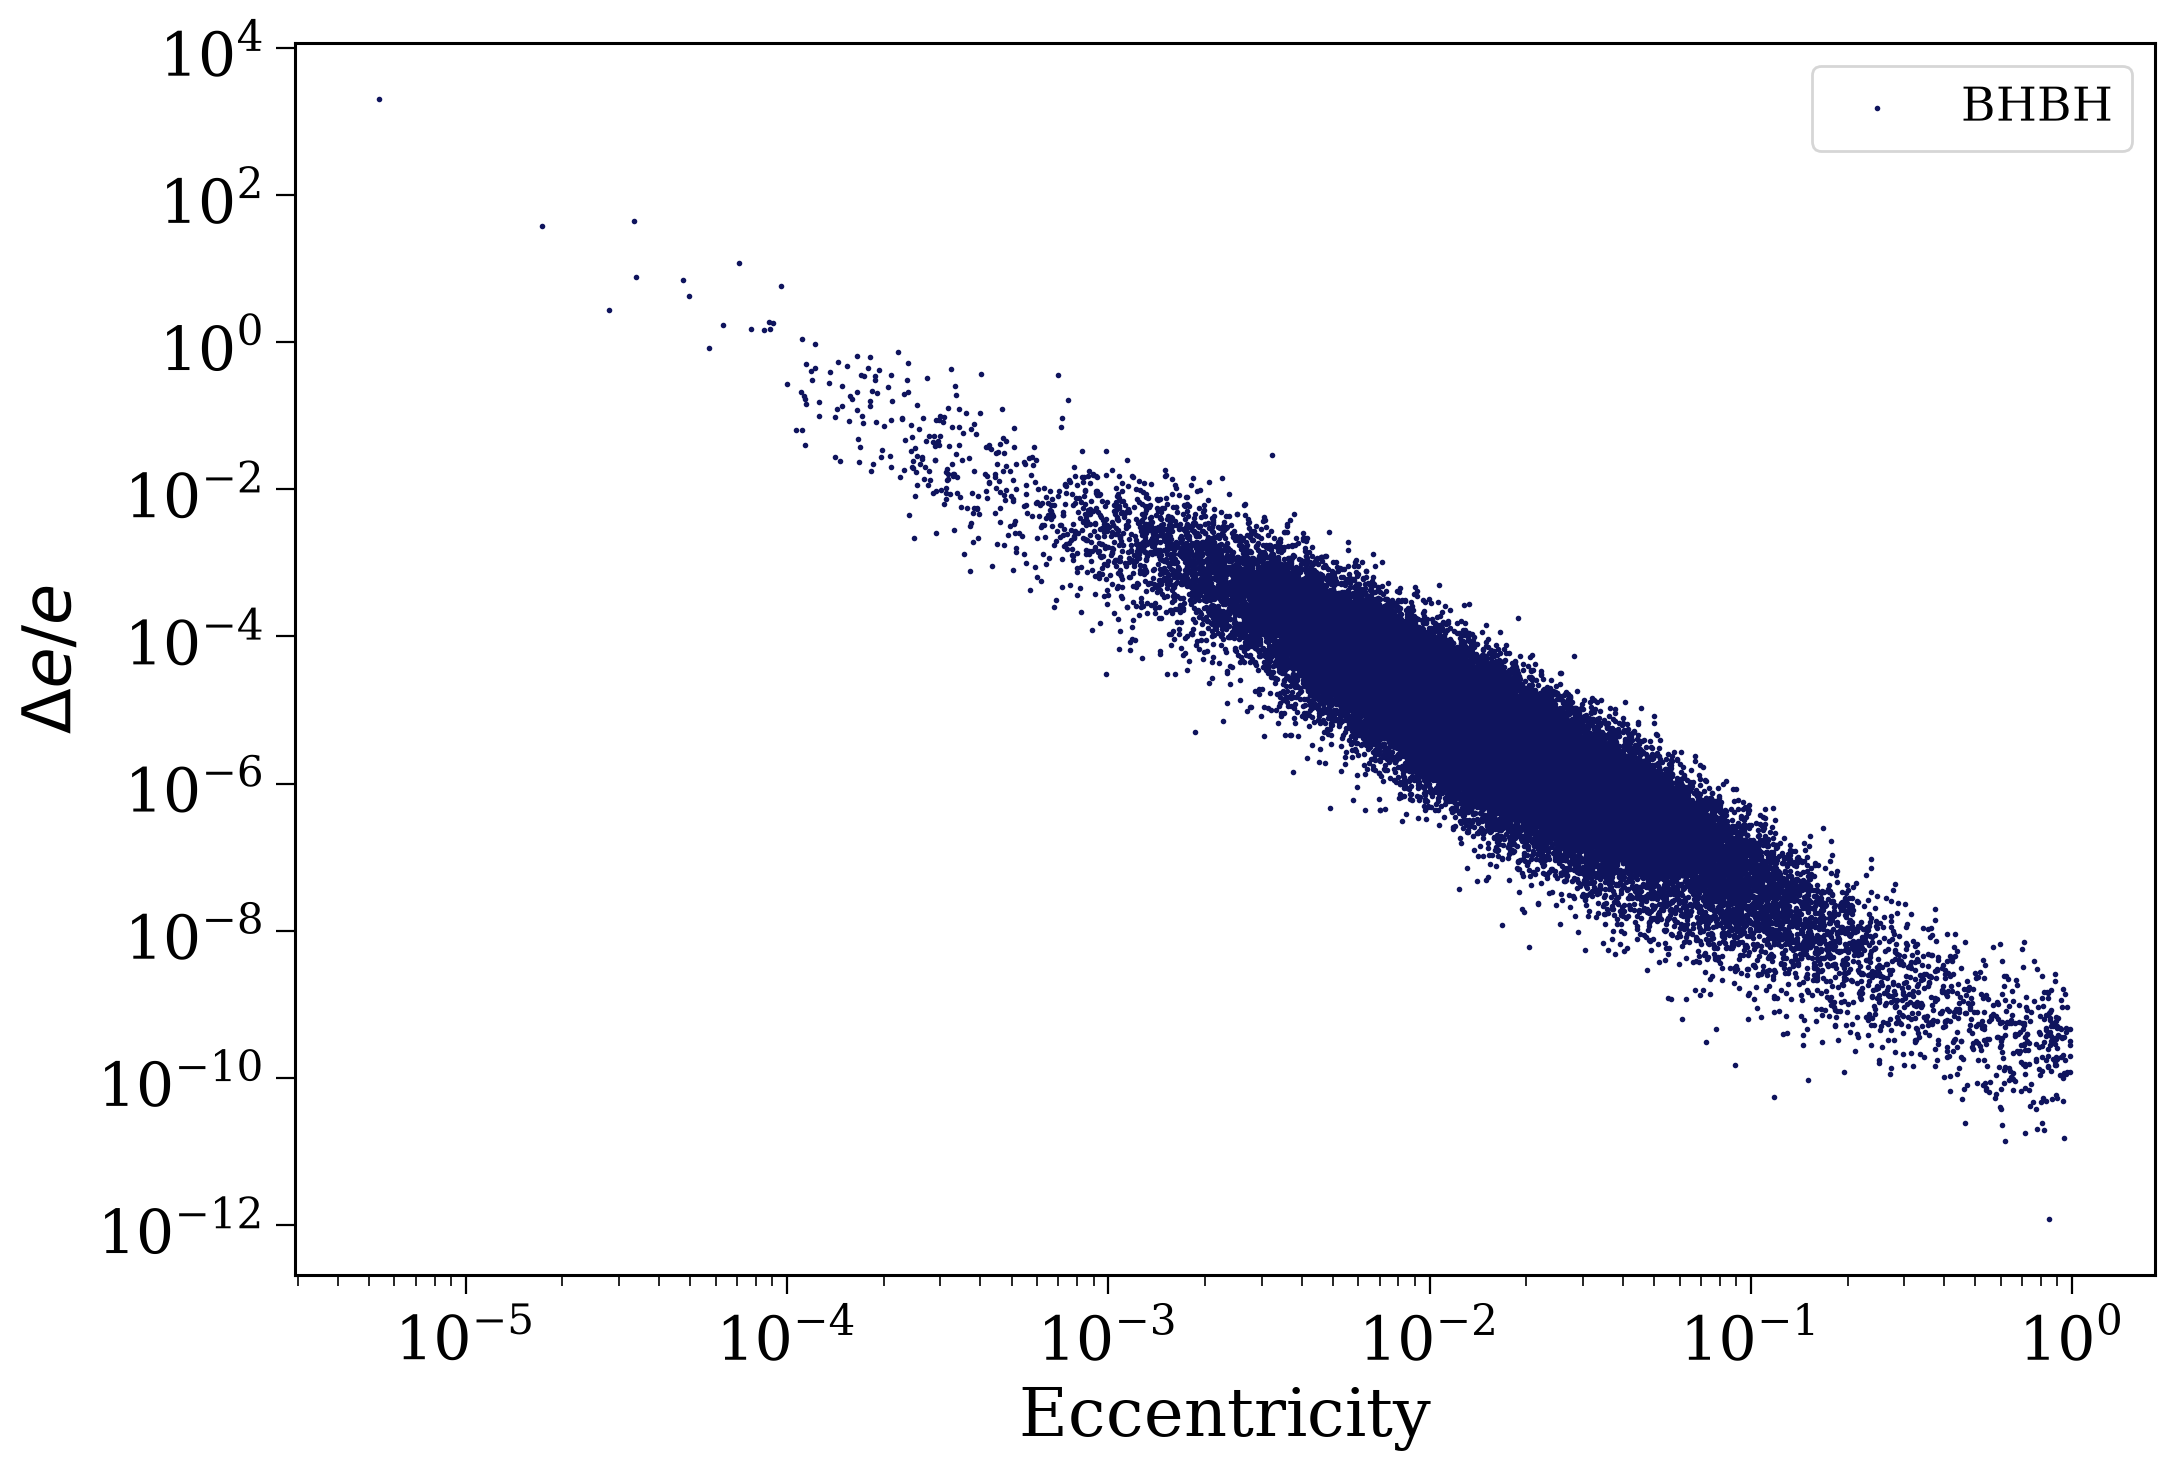

In [60]:
dco_type = "BHBH"
plt.scatter(lisa_4yr_sources[dco_type].ecc, nishizawa_uncertainty(lisa_4yr_sources[dco_type].dist, lisa_4yr_sources[dco_type].m_c, lisa_4yr_sources[dco_type].ecc) / lisa_4yr_sources[dco_type].ecc, s=1, c=const.DCO_COLOURS[dco_type], label=dco_type)
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlabel("Eccentricity")
plt.ylabel(r"$\Delta e / e$")

(0.0, 2.0)

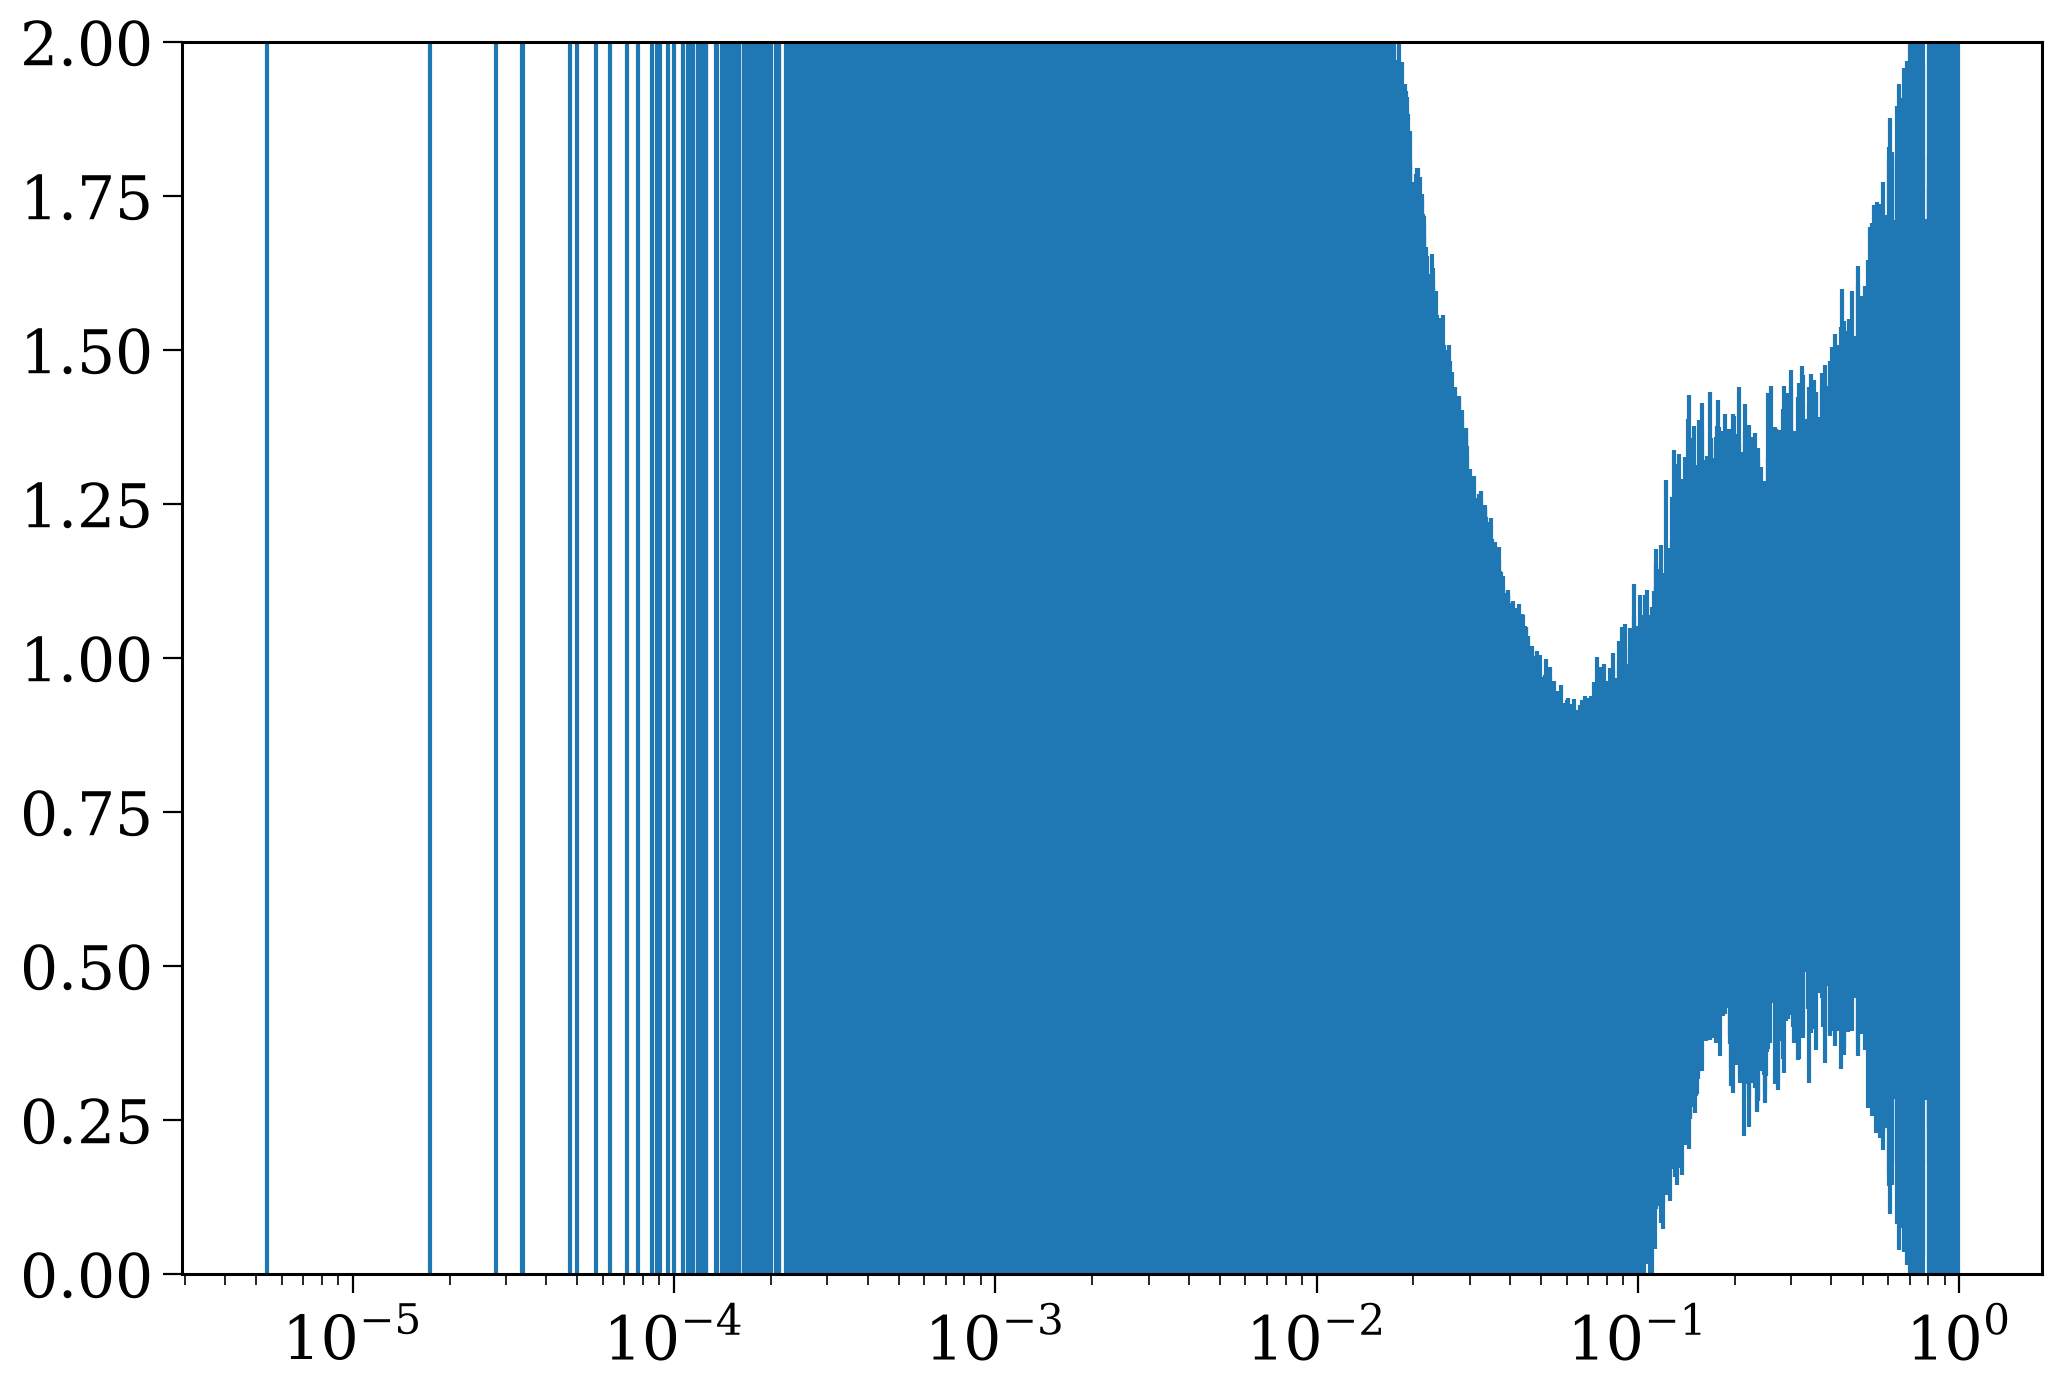

In [20]:
plt.errorbar(lisa_4yr_sources["BHBH"].ecc, unc_data["BHBH"]["snr_ratio"], yerr=unc_data["BHBH"]["snr_uncertainty"], linestyle="none")
plt.xscale("log")
plt.ylim(0, 2)

BHBH
BHNS
BHWD


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7487: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7488: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: It looks like the provided 'range' is not valid or the sample is empty.

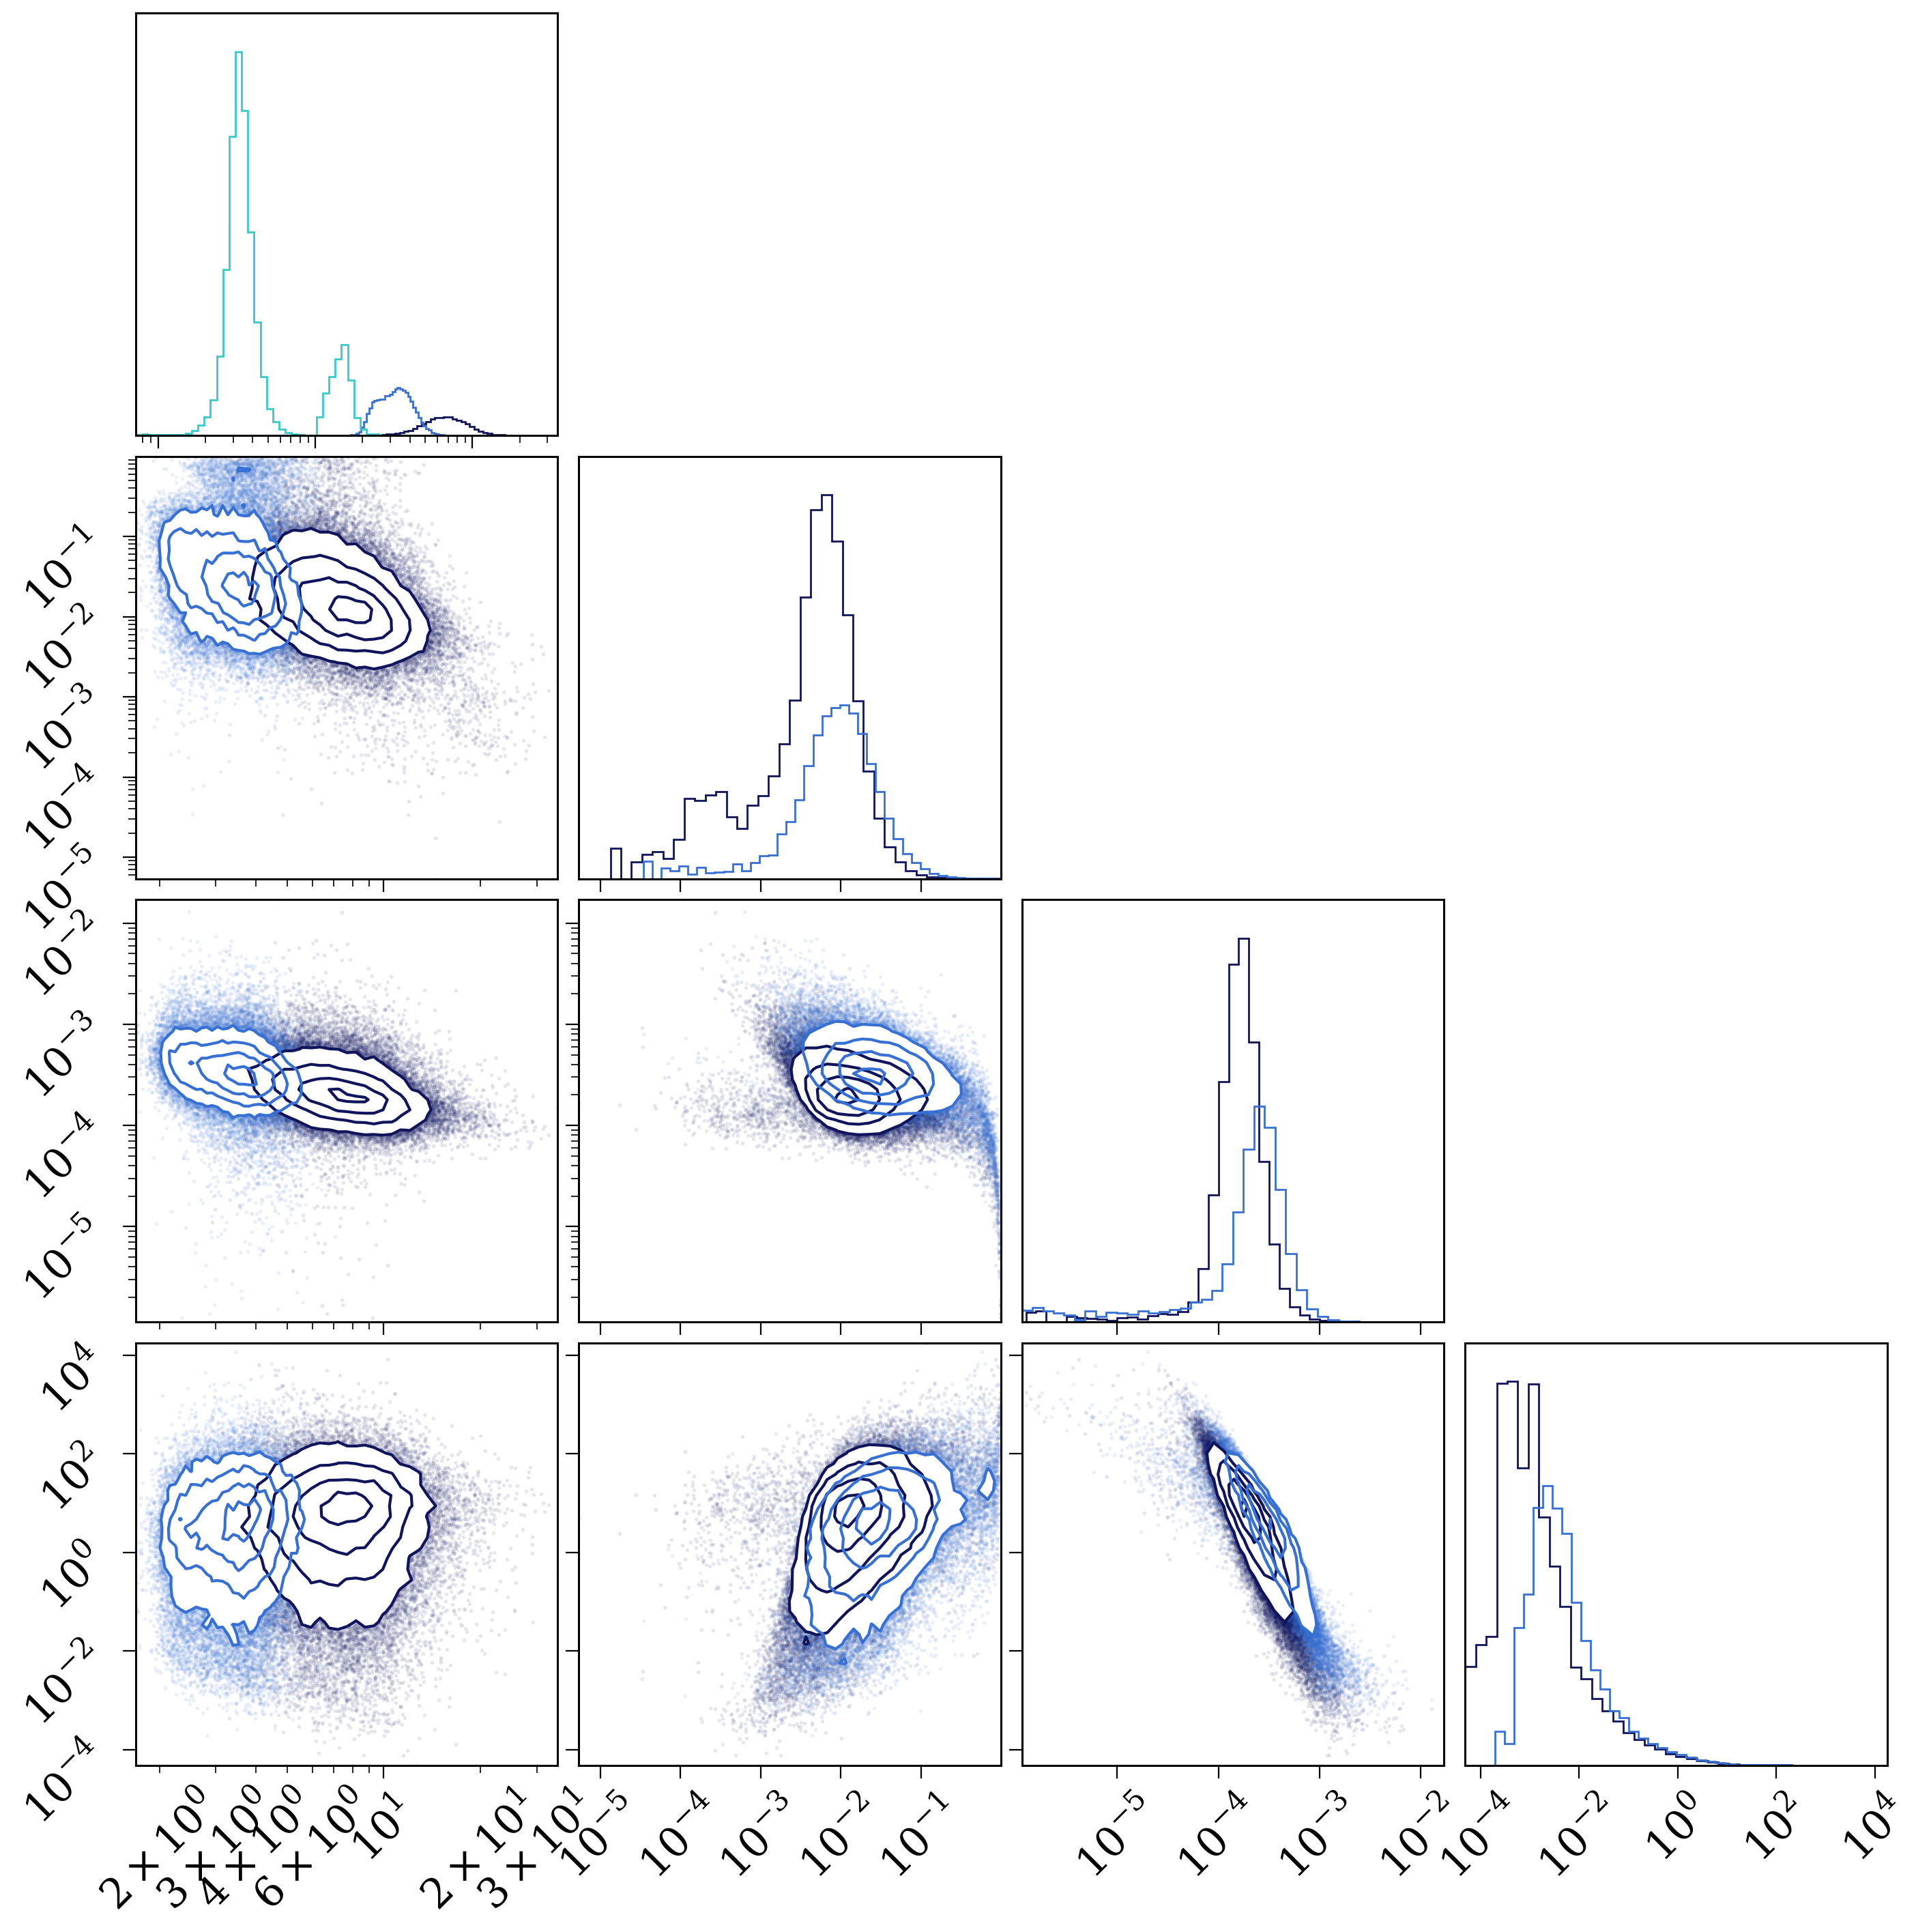

In [24]:
fig = plt.figure(figsize=(15, 15))

for dco_type in const.DCO_TYPES:
    print(dco_type)
    corner.corner(
        np.vstack([
            lisa_4yr_sources[dco_type].m_c.value,
            lisa_4yr_sources[dco_type].ecc if dco_type != "BHWD" else np.full(len(lisa_4yr_sources[dco_type].ecc), np.nan),
            lisa_4yr_sources[dco_type].f_orb.value,
            unc_data[dco_type]["delta_m_c_over_m_c"].value,
        ]).T,
        # range=[
        #     (0.1, 30),
        #     (1e-4, 1),
        #     (1e-5, 1e-2),
        #     (1e-8, 1e1)
        # ],
        axes_scale="log",
        color=const.DCO_COLOURS[dco_type],
        bins=40,
        fig=fig,
        plot_datapoints=True,
        plot_density=False,
        hist_kwargs={"density": True}
    )
    # break

plt.show()

In [17]:
unc_data["BHBH"]

{'snr_uncertainty': array([2.29055275, 0.31059587, 1.35273674, ..., 0.90499006, 1.37498169,
        0.60371407], shape=(50559,)),
 'snr_ratio': array([0.05418354, 0.48661857, 0.11054922, ..., 0.09291536, 0.08643689,
        0.16276274], shape=(50559,)),
 'detectable_harmonics': array([1, 2, 1, ..., 1, 1, 1], shape=(50559,)),
 'max_harmonics': array([2, 2, 2, ..., 2, 2, 2], shape=(50559,)),
 'delta_m_c_over_m_c': <Quantity [ 3.7822038 ,  3.10091156, 12.86159703, ..., 10.38988222,
            13.53569636,  9.86730712]>,
 'sigma_theta': <Quantity [15.5589149 ,  8.84638047, 18.08667187, ..., 14.66362682,
            18.21846068, 13.13509514] deg>,
 'delta_d_over_d': <Quantity [ 2.76188269,  2.37337838,  9.78716014, ...,  7.95365036,
            10.3424394 ,  7.56514724]>}

False
0.13079713385697186


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


False
0.4206441630107513
False
0.6452624672302932
False
0.8458384277820769
False
0.9298974520796098


[(0.0, 0.6256219710865115)]

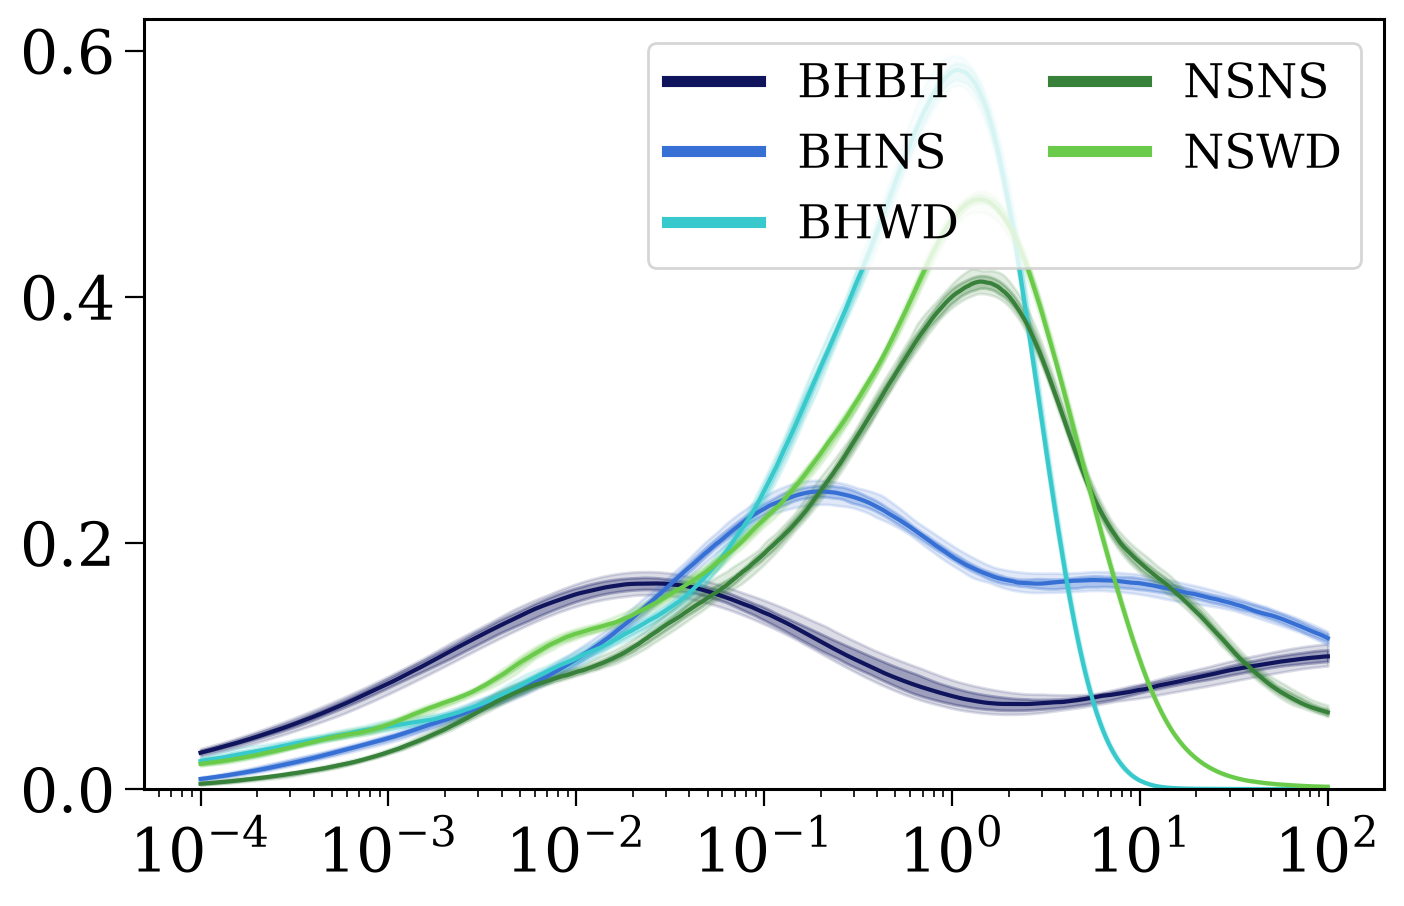

In [ ]:
reload(plotting)
reload(unc)

fig, ax = plt.subplots(figsize=(8, 5))

for dco_type in const.DCO_TYPES:
    s = detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]
    w = lisa_4yr_pops[dco_type].initC["weights"]
    snr_uncertainty, snr_ratio, detectable_harmonics, max_harmonics = unc.get_ecc_uncertainty_stats(s, harmonic_threshold=2)
    print(np.isnan(snr_uncertainty).any())
    sigma_m_c = unc.get_m_c_uncertainty(
        s.f_orb,
        lw.utils.fn_dot(s.m_c, s.f_orb, s.ecc, n=1),
        s.ecc,
        snr_uncertainty,
        s.snr,
        4 * u.yr
    )
    mask = np.isfinite(np.log10(sigma_m_c))
    print(np.sum(w[mask]) / np.sum(w))
    # plt.hist(np.log10(s.m_c.value), bins=np.linspace(np.log10(0.3), np.log10(30), 100), weights=w, label=dco_type, histtype="step", lw=2.5, color=const.DCO_COLOURS[dco_type], density=True)
    plotting.bootstrapped_kde_fast(
        variable=np.log10(sigma_m_c[mask]), weights=w.values[mask], ax=ax, x_min=-4, x_max=2, bootstraps=50, x_count=500, bw_adjust=1, color=const.DCO_COLOURS[dco_type], label=dco_type
    )



plotting.fake_log_axis(ax, axis="x")

handles, labels = ax.get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(4)
ax.legend(handles, labels, loc="upper right", ncol=2)

ax.set(
    # xlabel=r"Chirp mass, $\log_{10}(\mathcal{M}_c / {\rm M_\odot})$",
    # ylabel=r"${\rm d}N / {\rm d}\log_{10}(\mathcal{M}_c / {\rm M_\odot})$",
    # xlim=(-4, 0),
    ylim=(0, None)
)

# plt.savefig("../plots/m_chirp_lisa.pdf", bbox_inches="tight")

In [276]:
import uncertainties as unc
snr_uncertainty, snr_ratio, detectable_harmonics, max_harmonics = unc.get_ecc_uncertainty_stats(sources, harmonic_threshold=2)
min_ratio = np.clip(snr_ratio - snr_uncertainty, 0, None)

NameError: name 'sources' is not defined

In [73]:
sigma_m_c = unc.get_m_c_uncertainty(
    sources.f_orb,
    lw.utils.fn_dot(sources.m_c, sources.f_orb, sources.ecc, n=1),
    sources.ecc,
    snr_uncertainty,
    sources.snr,
    4 * u.yr
)
sky_localisation = unc.sky_localisation(
    sources.snr,
    sources.f_orb * 2,
)

In [54]:
(sigma_m_c < 1).sum() / len(sources)

np.float64(0.2820031144177769)

In [81]:
theta = np.arctan(np.abs(pop.final_pos[:, 2]) / sources.dist).to(u.deg)
sigma_theta = sky_localisation / theta

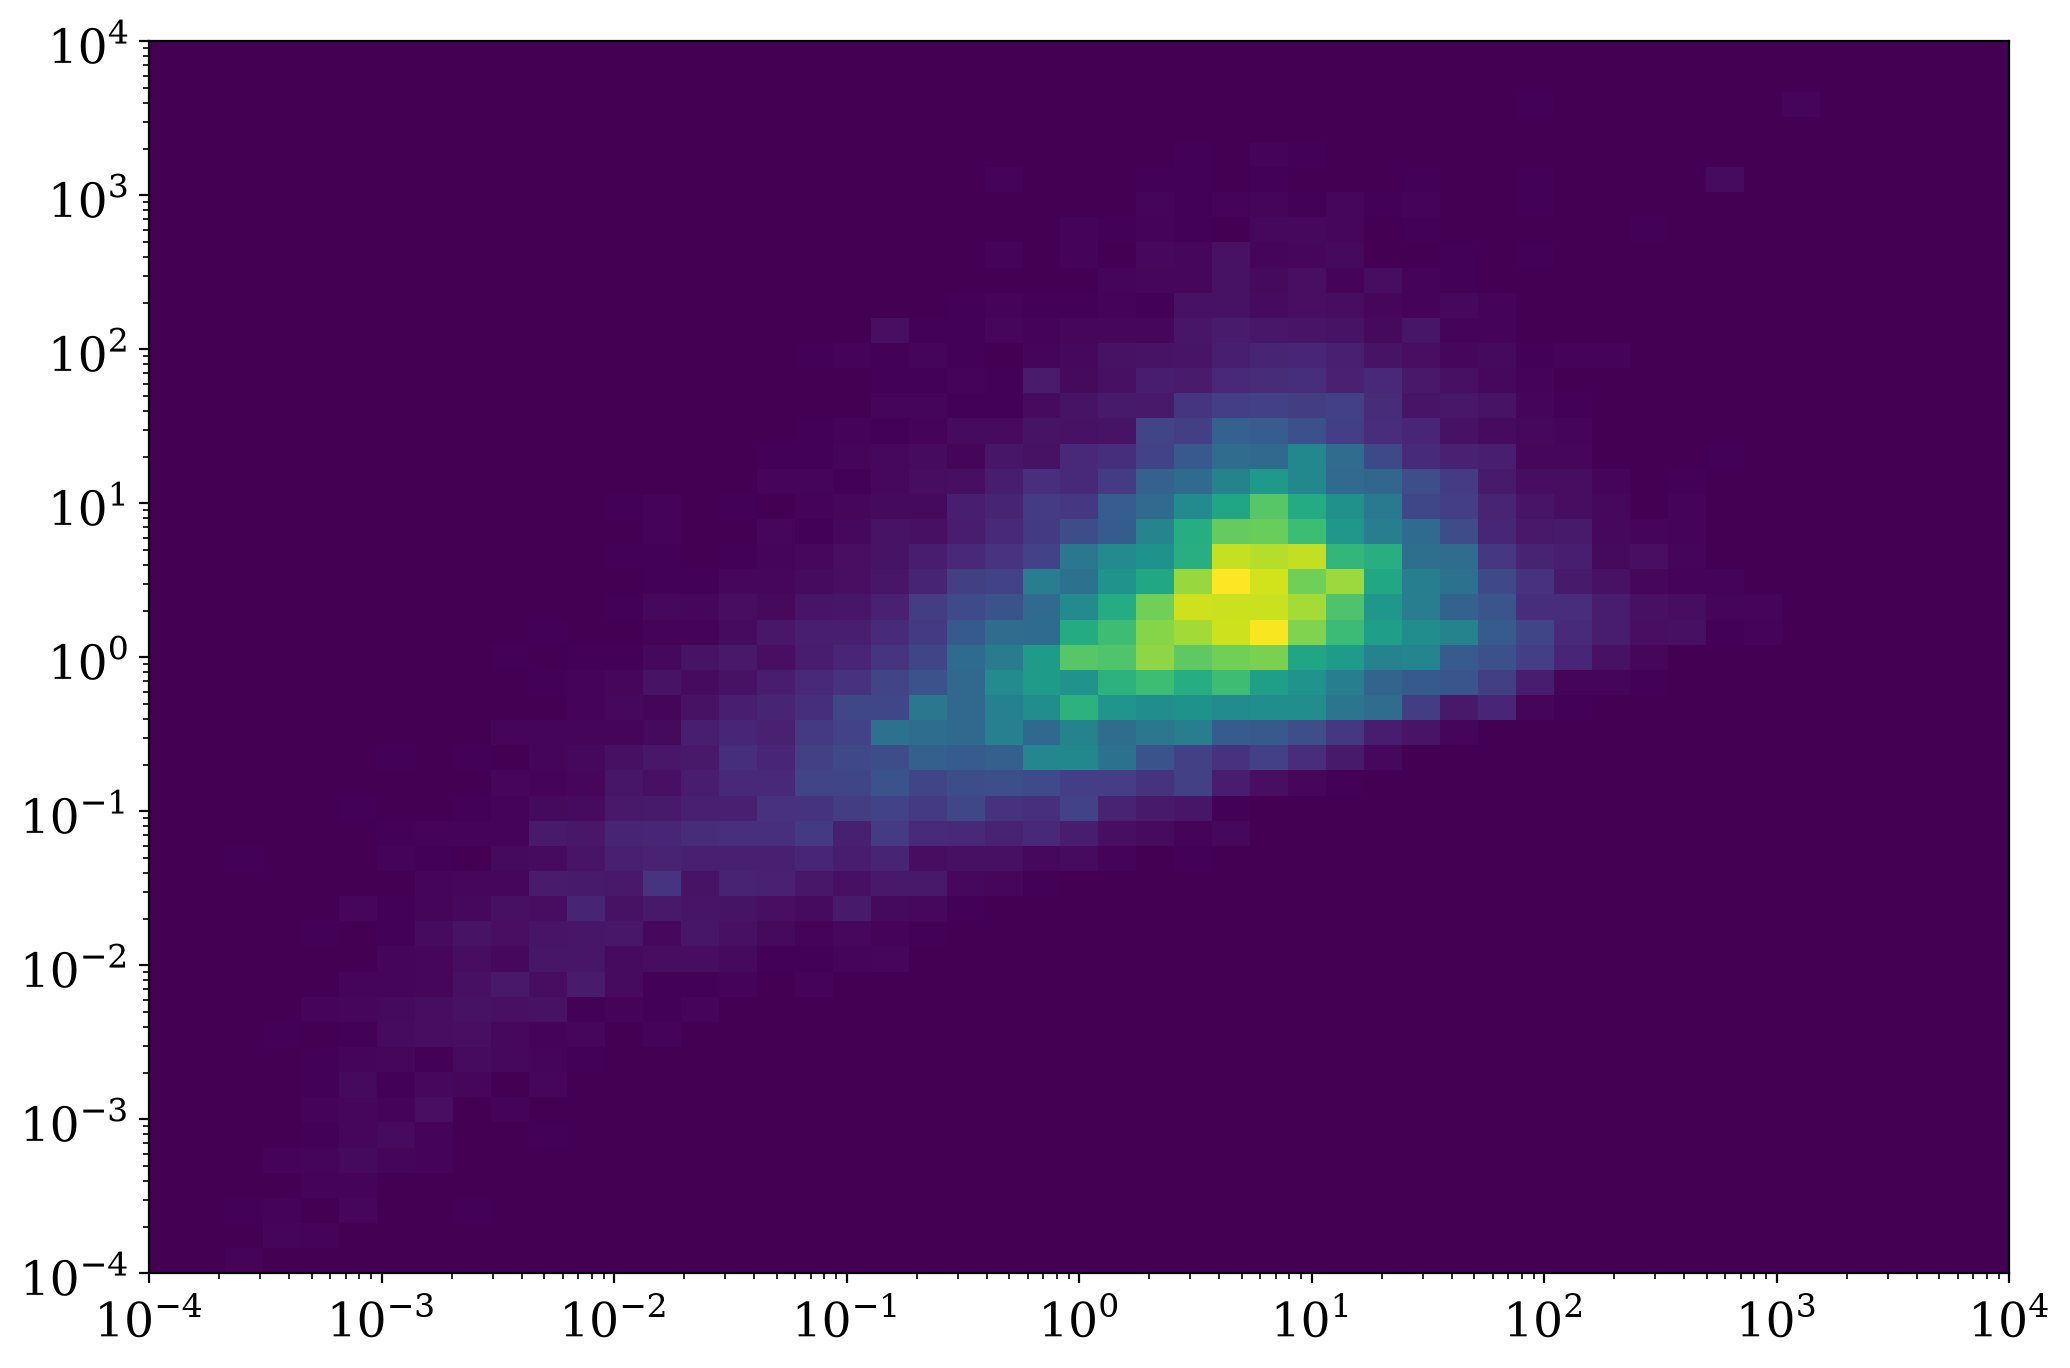

In [109]:
fig, ax = plt.subplots()

# ax.scatter(sigma_m_c, sigma_theta, s=10 * pop.initC["weights"])
ax.hist2d(
    sigma_m_c, sigma_theta, weights=pop.initC["weights"],
    bins=(np.logspace(-4, 4, 50), np.logspace(-4, 4, 50)),
)

ax.set(
    xscale="log", yscale="log"
)

plt.show()

In [92]:
massive = (sources.m_c - sigma_m_c * sources.m_c) > 1.2 * u.Msun
np.sum(pop.initC["weights"][massive]) / np.sum(pop.initC["weights"])

np.float64(0.26309124575862025)

In [93]:
away_from_plane = np.arcsin(1 * u.kpc / sources.dist) - sky_localisation > 0 * u.deg
np.sum(pop.initC["weights"][away_from_plane]) / np.sum(pop.initC["weights"])

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in arcsin
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)



np.float64(0.35030998842773653)

[None, None]

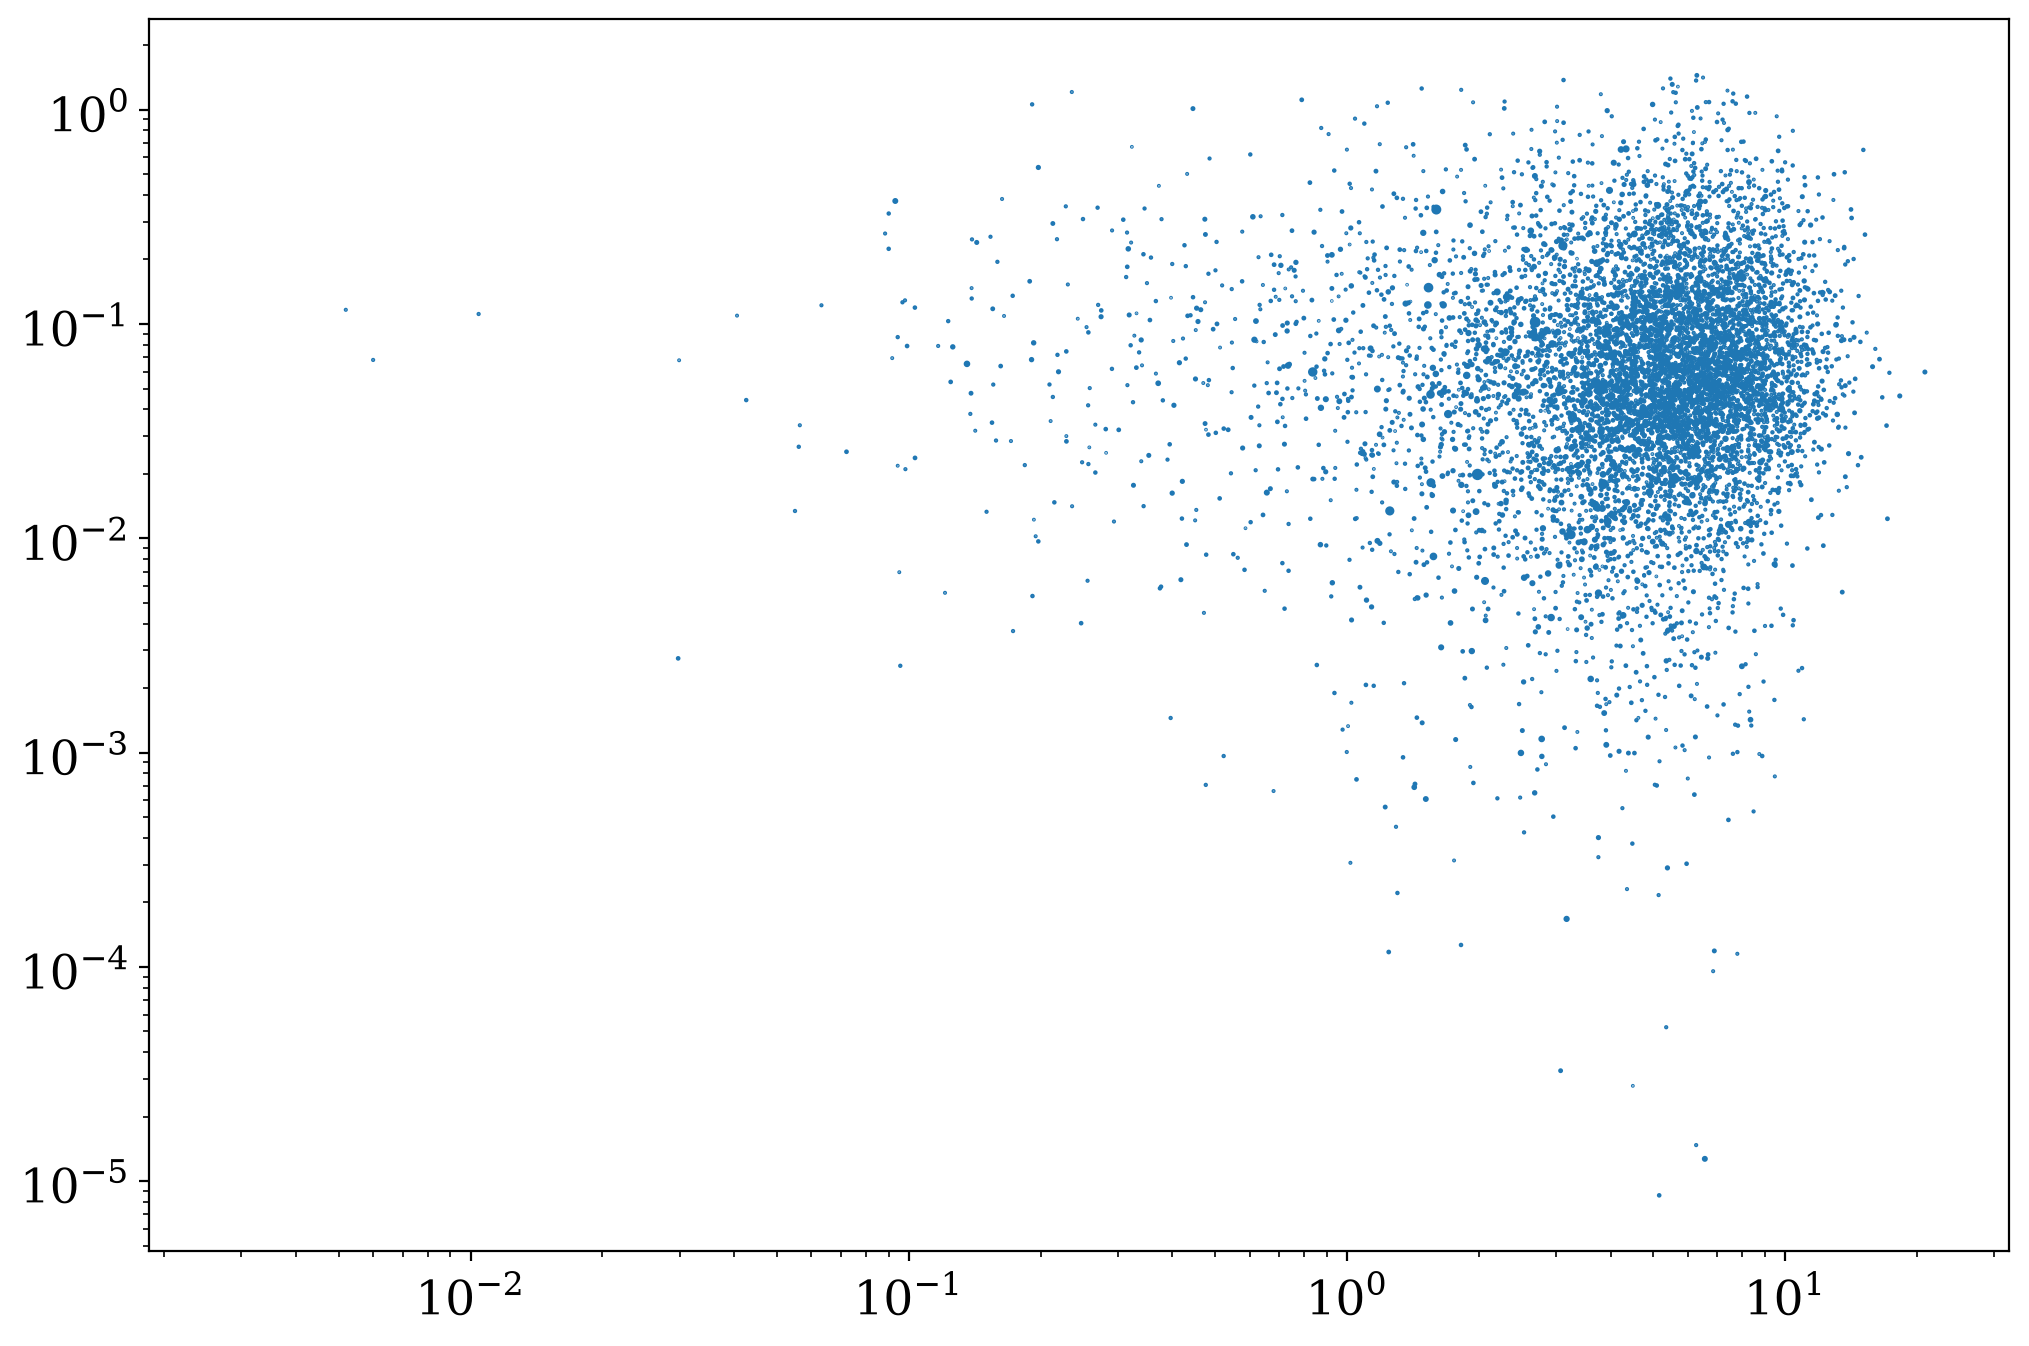

In [94]:
fig, ax = plt.subplots()

ax.scatter(sources.m_c - sigma_m_c * sources.m_c - 1.2 * u.Msun, np.arcsin(1 * u.kpc / sources.dist) - sky_localisation, s=10 * pop.initC["weights"])

ax.set(
    xscale="log", yscale="log"
)

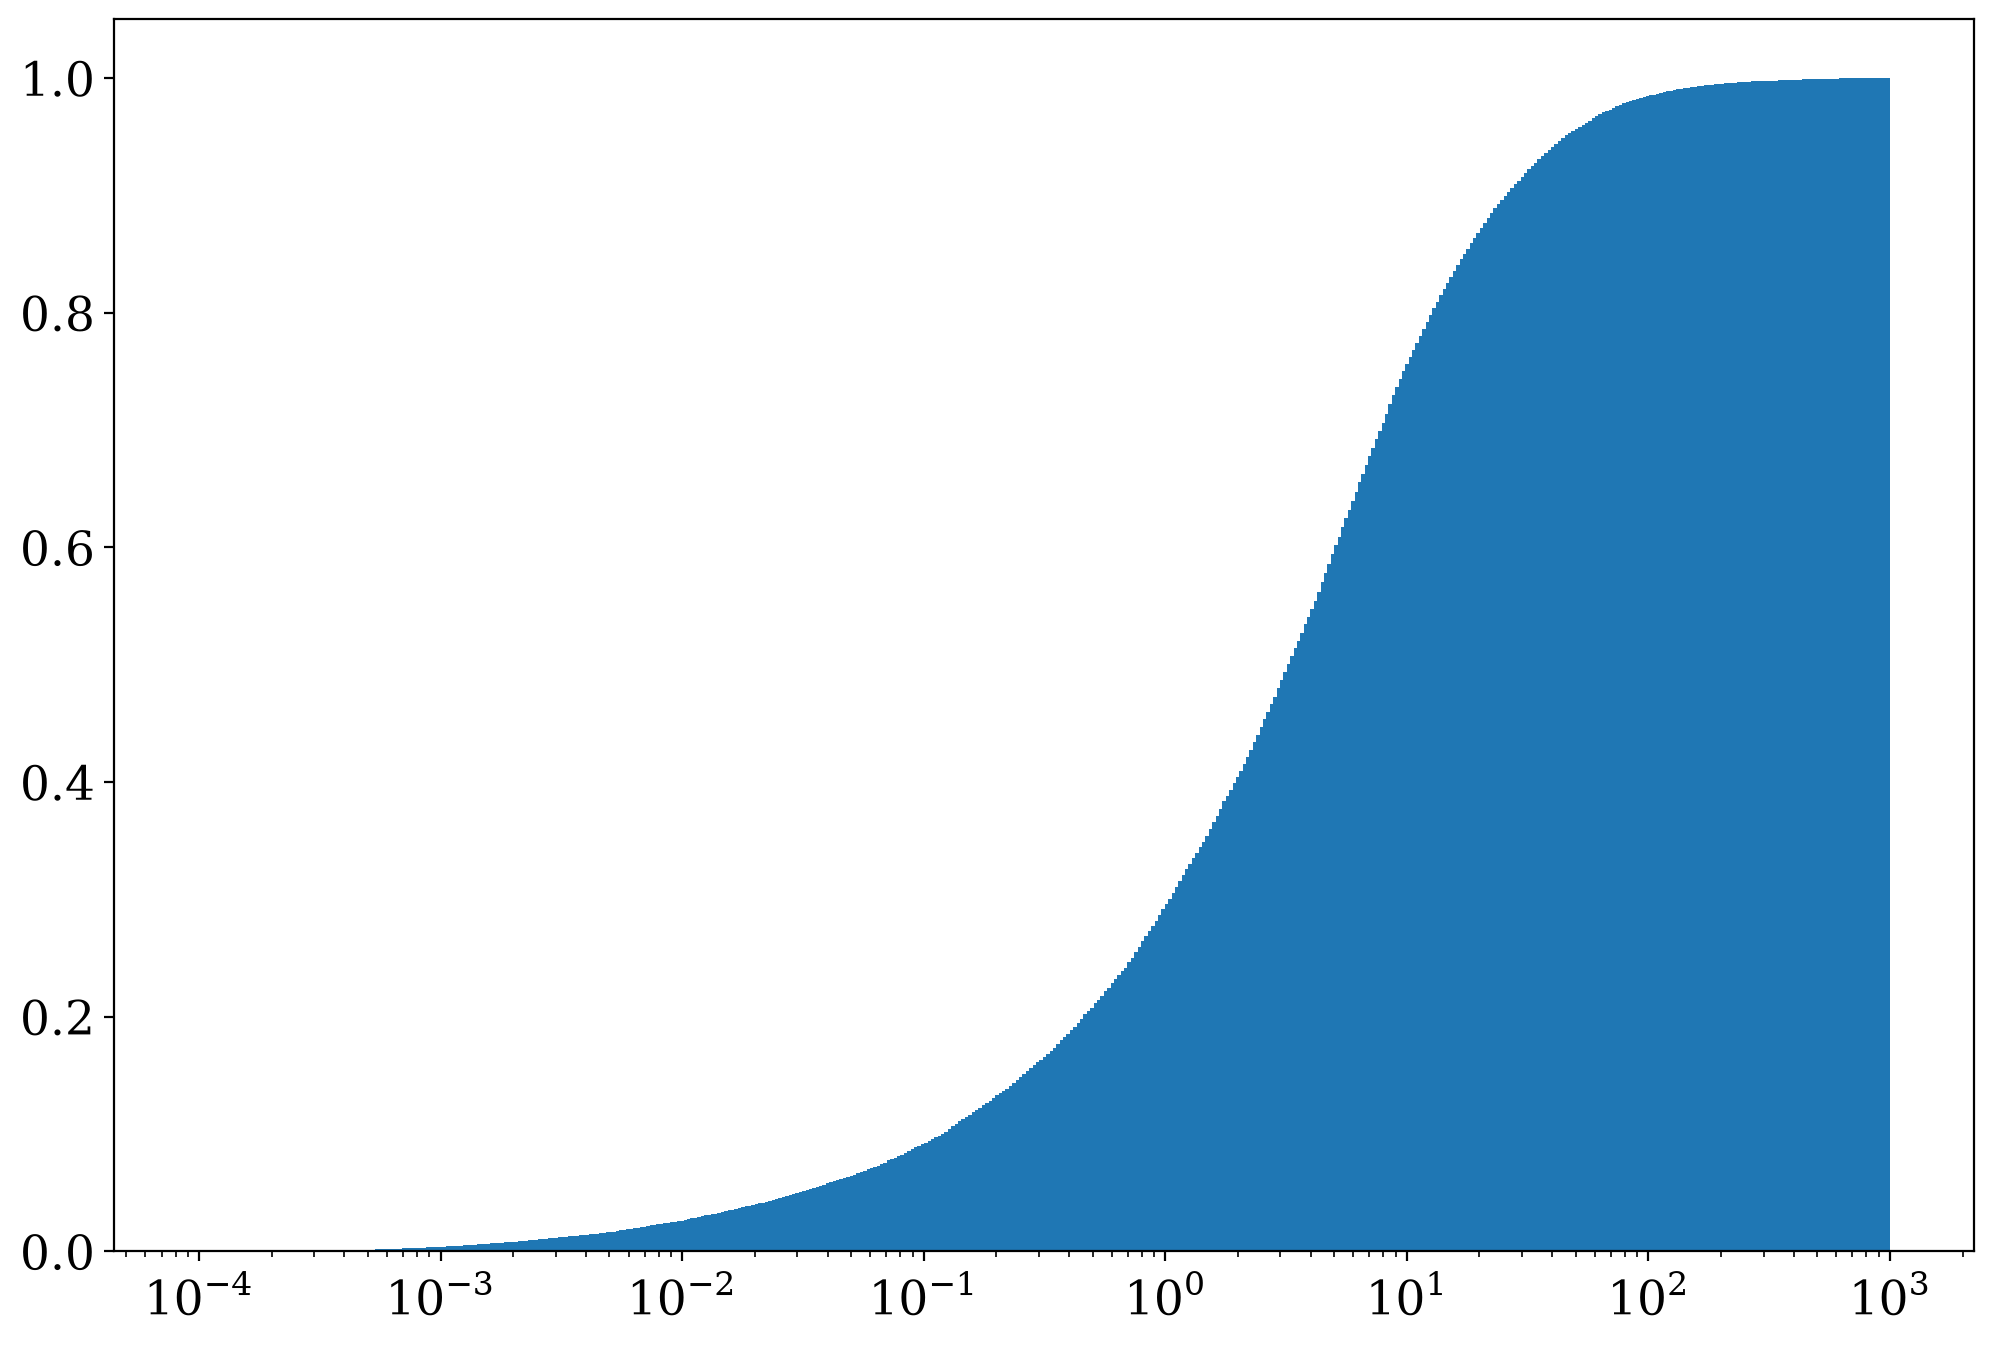

In [56]:
plt.hist(sigma_m_c, cumulative=True, bins=np.logspace(-4, 3, 500), density=True, weights=pop.initC["weights"])
plt.xscale("log")

In [45]:
ranges = [(0, 1), (1e-3, 1), (0.01, 1), (0.1, 1)]
for lo, hi in ranges:
    in_range = min_ratio[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_dh = detectable_harmonics[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_weights = pop.initC["weights"][(min_ratio >= lo) & (min_ratio <= hi)]
    print(np.sum(in_range_weights[((in_range > 1e-2) & (in_range_dh >= 2))]) / np.sum(in_range_weights) * 100)

2.348066994123517
94.6580839559977
100.0
100.0


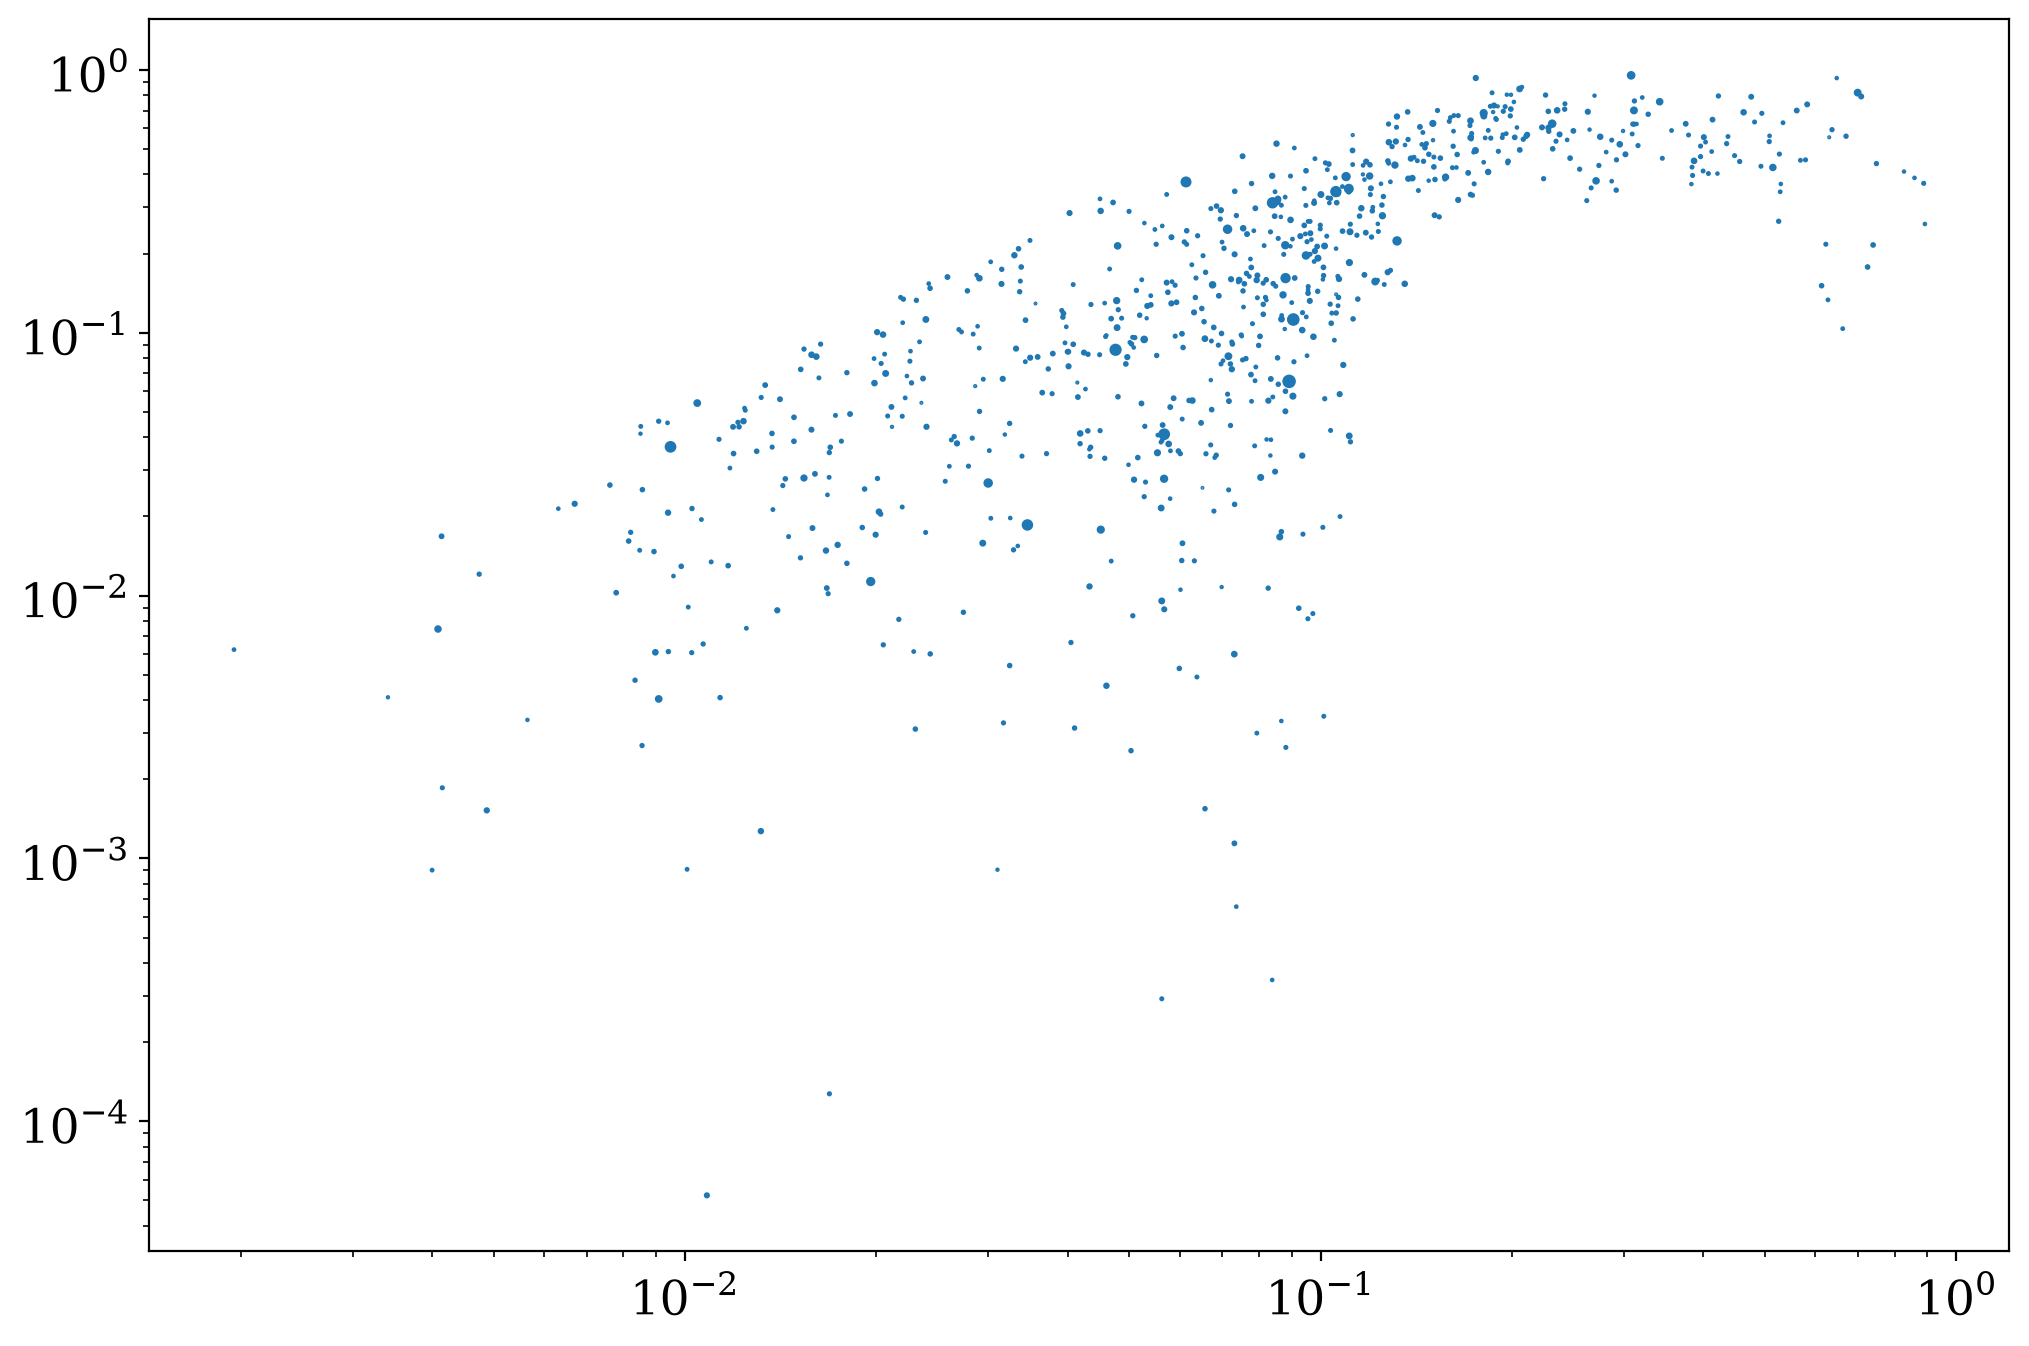

In [157]:
plt.scatter(sources.ecc[min_ratio > 0], min_ratio[min_ratio > 0], s=20 * pop.initC["weights"][min_ratio > 0])
plt.xscale("log")
plt.yscale("log")

In [133]:
snr_ratio - snr_uncertainty > 0.01

array([False, False, False, ..., False, False, False], shape=(40457,))

In [130]:
snr_uncertainty

array([2.00081009, 0.67625843, 0.48317602, ..., 1.15830565, 0.90784628,
       2.5251525 ], shape=(40457,))

In [122]:
np.unique(detectable_harmonics, return_counts=True)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  18,  20,  21,  24,  25,  26,  29,  30,  31,
         32,  34,  35,  38,  39,  40,  77,  86,  94, 104, 111, 119, 122,
        438]),
 array([    4, 26397, 13387,   423,   102,    35,    18,    14,    13,
           21,     1,     1,     1,     1,     2,     3,     2,     3,
            4,     1,     1,     2,     2,     1,     1,     1,     1,
            2,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     2,     1]))

(array([1.51398157e+03, 2.00997843e+02, 4.33131828e+01, 1.57982183e+01,
        9.42439195e+00, 3.98070171e+00, 1.95968241e+00, 1.15113174e+00,
        1.40141247e+00, 7.82763234e-01, 4.63015850e-01, 7.91387956e-01,
        2.86779855e-01, 3.59012173e-01, 3.28290460e-01, 6.28128792e-01,
        2.28431397e-01, 2.70199173e-02, 2.74214888e-01, 2.35491963e-01,
        1.50444793e-01, 1.05450229e-01, 1.31183932e-01, 9.46356100e-02,
        1.34117795e-01, 2.70476790e-01, 2.87050995e-02, 9.25865902e-02,
        9.86890548e-02, 1.15166773e-01, 1.26995257e-01, 1.96843180e-01,
        7.08816876e-02, 7.05811872e-02, 2.35135248e-01, 1.56670347e-01,
        9.65398553e-02, 3.48772758e-02, 0.00000000e+00, 0.00000000e+00,
        1.99241923e-01, 0.00000000e+00, 2.23142217e-02, 2.82655911e-01,
        3.60970219e-01, 0.00000000e+00, 0.00000000e+00, 6.31949301e-01,
        1.74192475e-01]),
 array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
        0.10204082, 0.12244898, 0.14285714

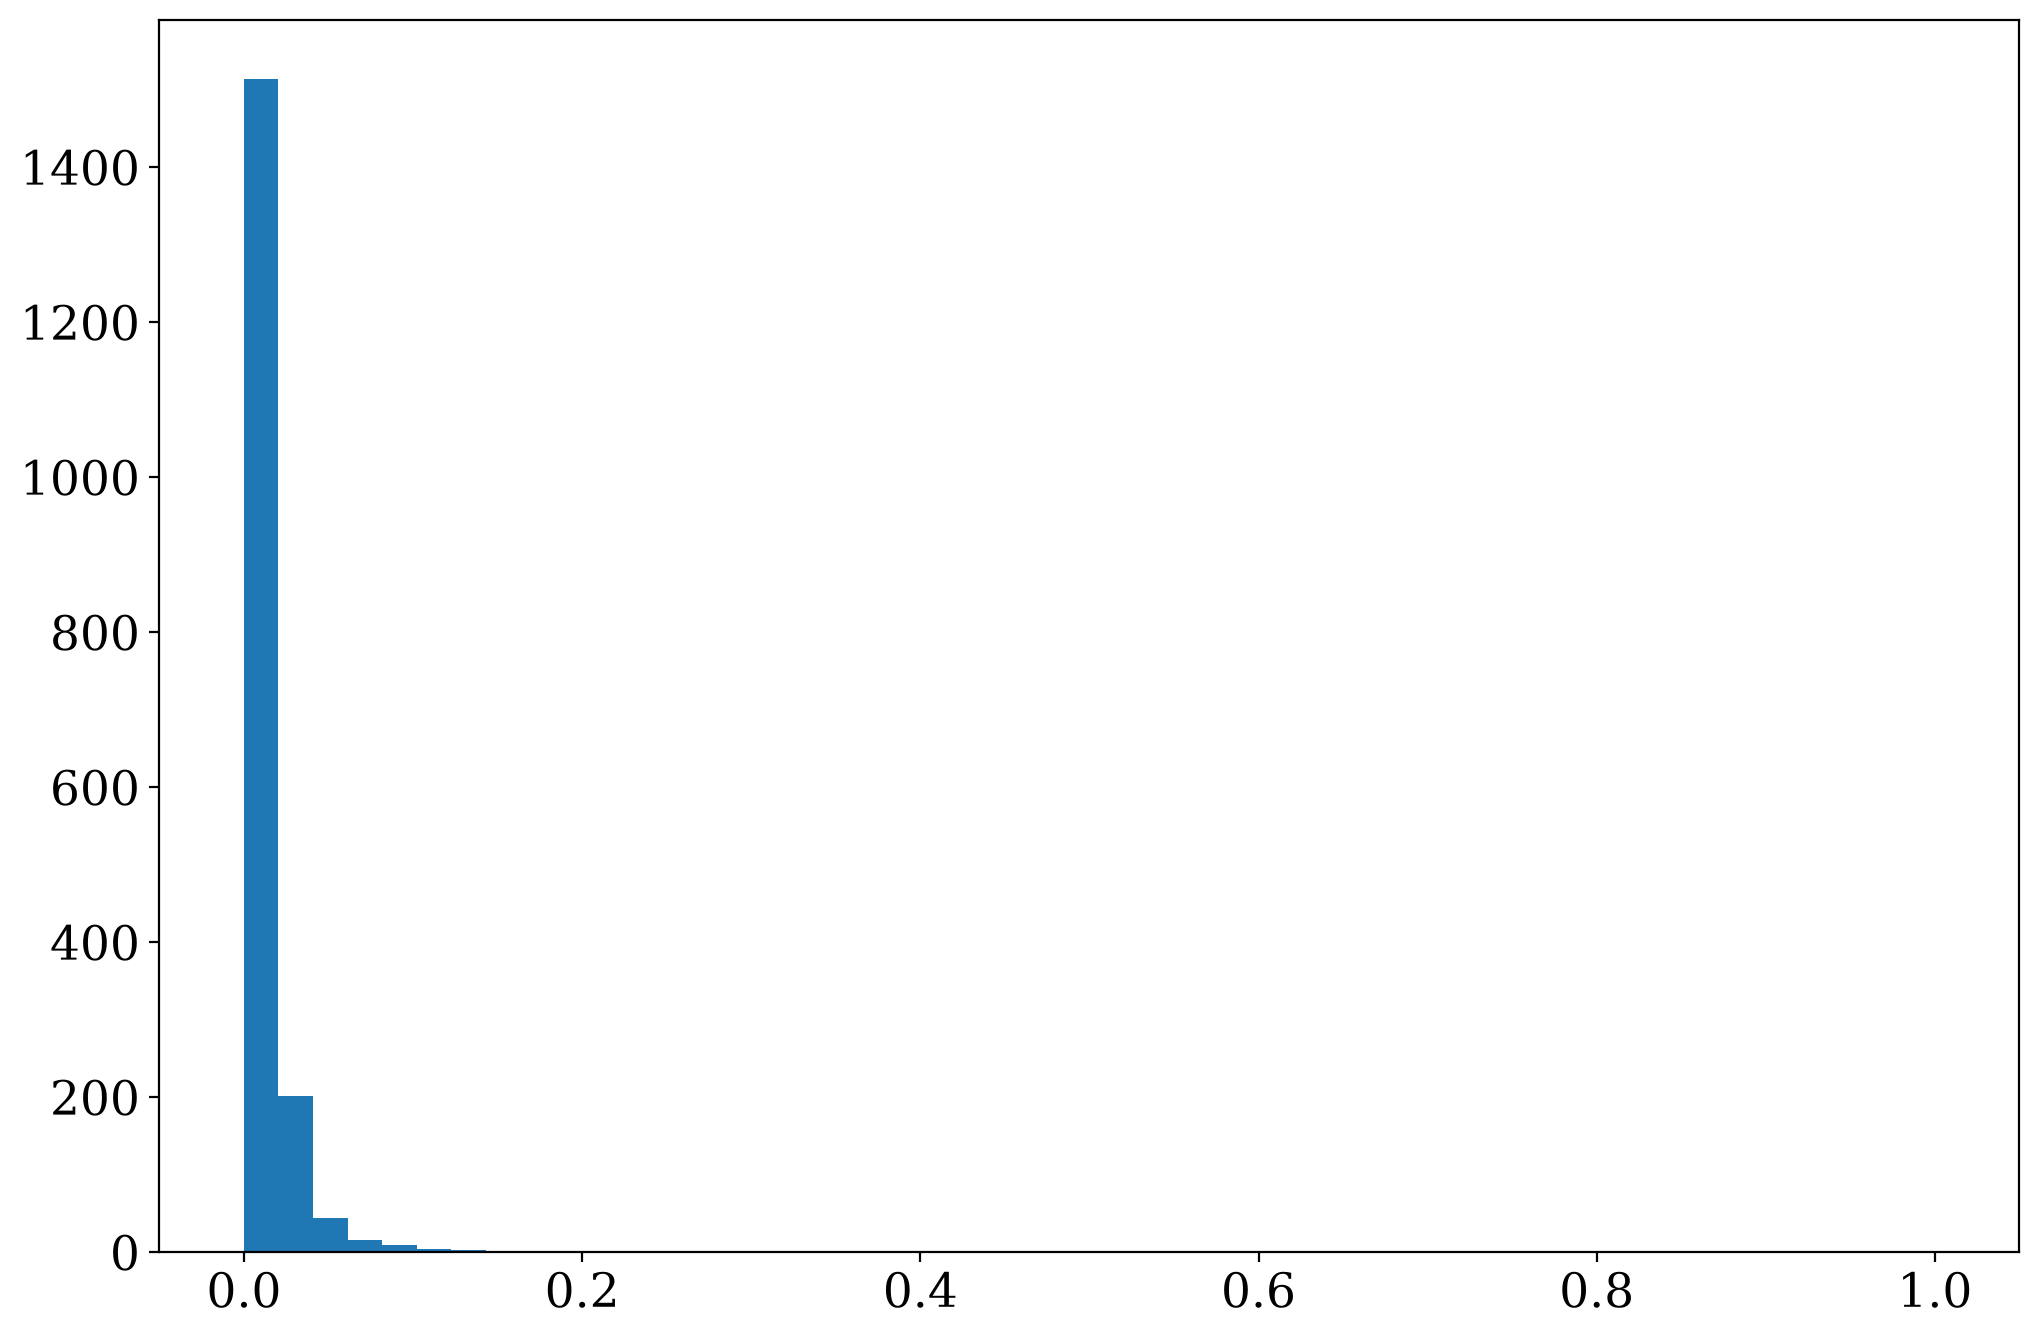

In [129]:
plt.hist(sources.ecc, weights=pop.initC["weights"], bins=np.linspace(0, 1, 50))

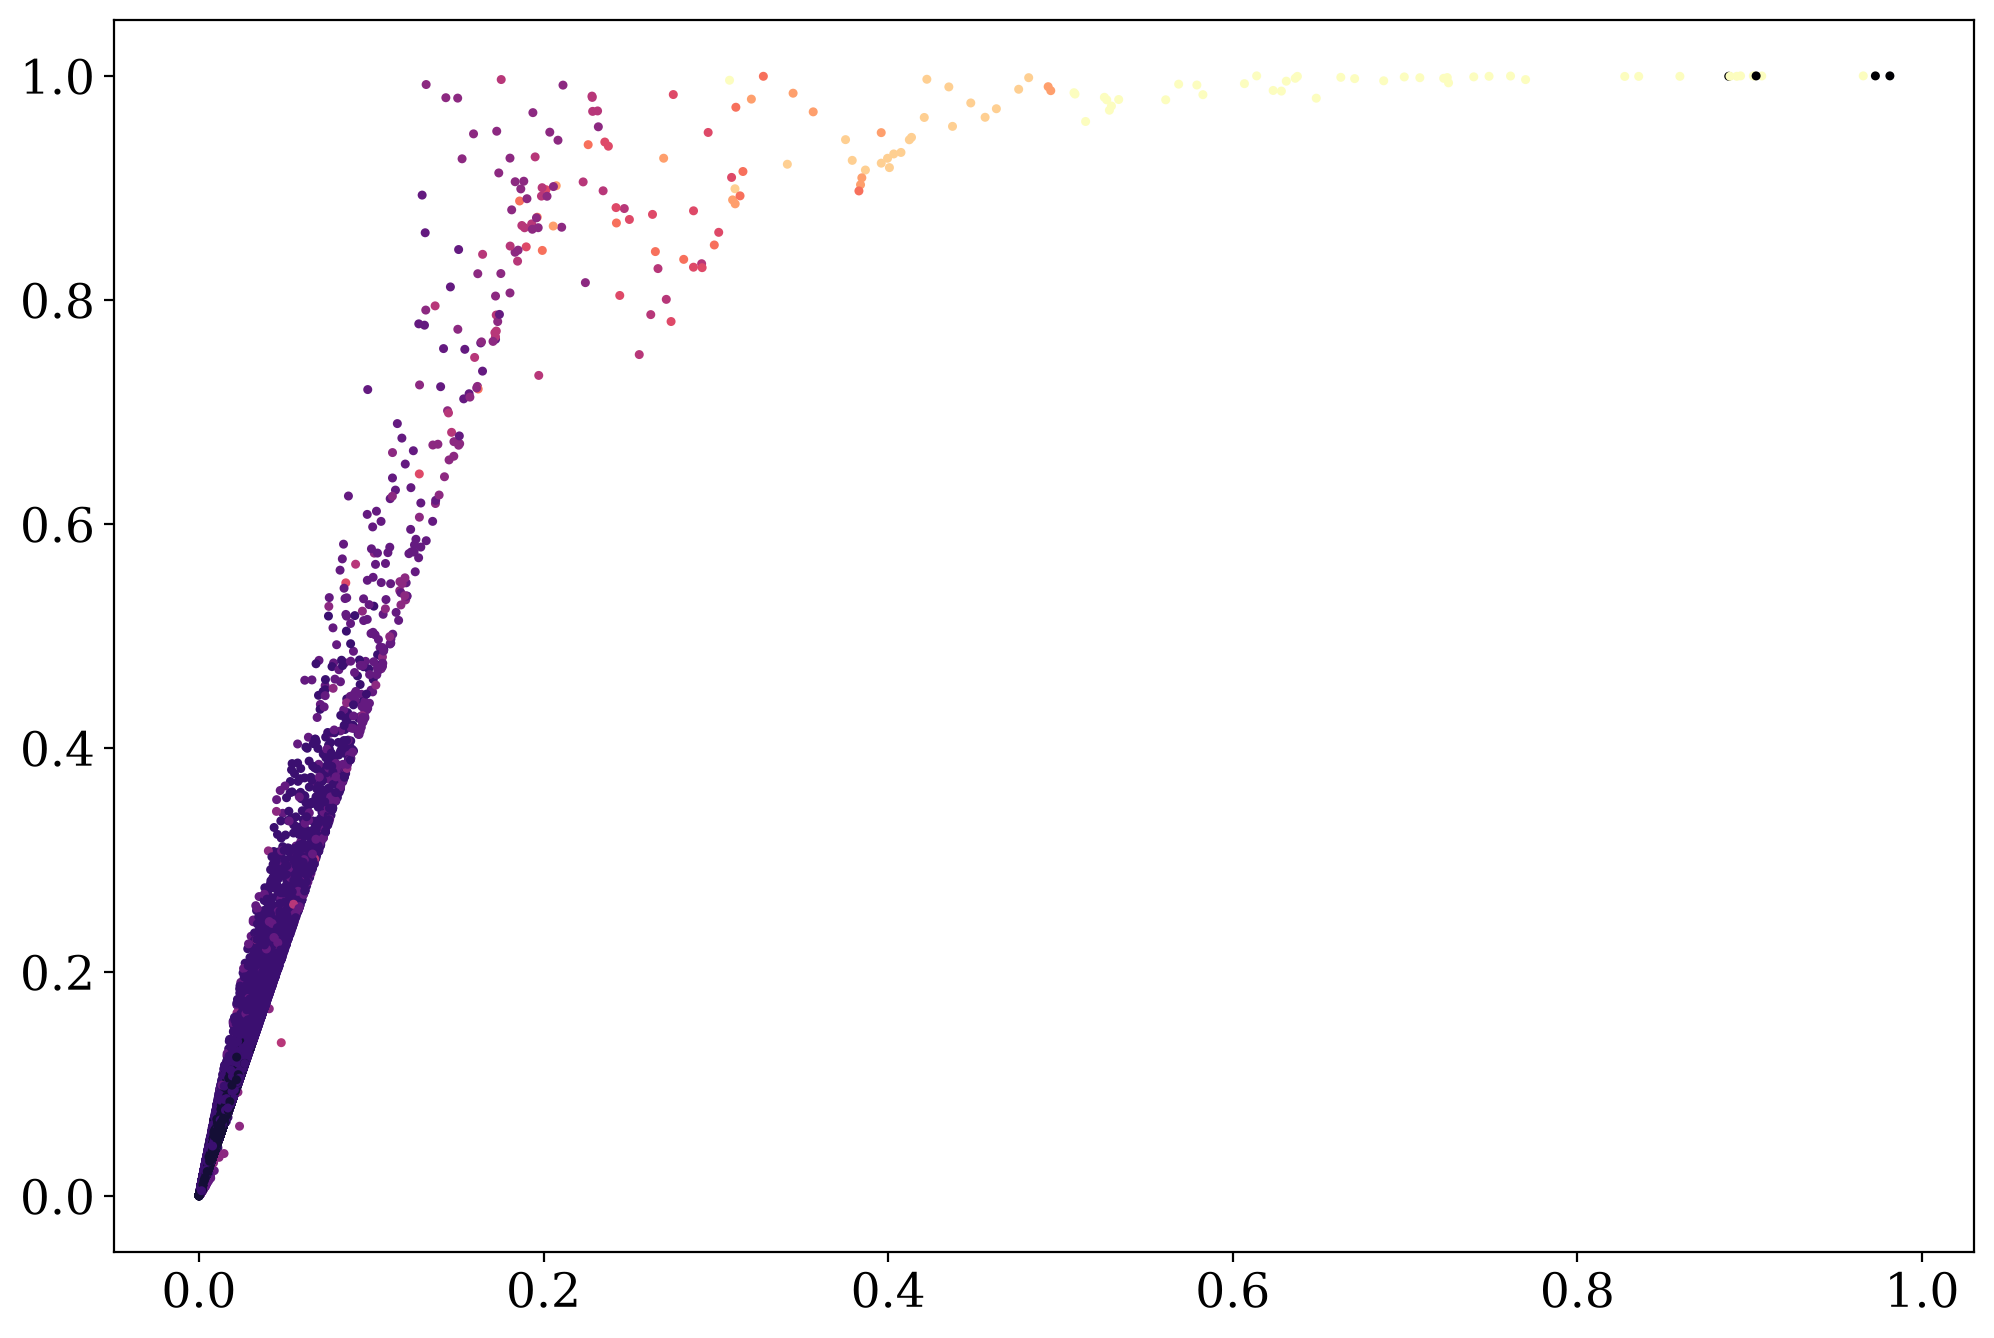

In [125]:
plt.scatter(sources.ecc, p_ecc, c=detectable_harmonics, vmin=0, vmax=10, cmap="magma", s=5)